# Predição de Tempos de Volta em Corridas de Fórmula 1
## Grande Prêmio da Itália (2022-2025): Análise Temporal e Modelagem Preditiva

---

## 1. Configuração Inicial - Importações e Setup

In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import os
import json
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import scipy.stats as stats
import statsmodels.api as sm
import xgboost as xgb
import optuna
import shap
from sklearn.ensemble import RandomForestRegressor

CACHE_DIR = './fastf1_cache'
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)
print(f"FastF1 cache enabled at: {os.path.abspath(CACHE_DIR)}")

BASE_PLOT_DIR = './f1_plots'
if not os.path.exists(BASE_PLOT_DIR):
    os.makedirs(BASE_PLOT_DIR)
print(f"Base directory for saving plots: {os.path.abspath(BASE_PLOT_DIR)}")

C:\Users\mpoli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FastF1 cache enabled at: c:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Scripts\fastf1_cache
Base directory for saving plots: c:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Scripts\f1_plots


---

## 2. Extração de Dados Multitemporal (2022-2025)

### Objetivo
Realizar a coleta automatizada de dados de telemetria, cronometragem e condições ambientais para o **Grande Prêmio da Itália** ao longo de múltiplas temporadas da era de motores híbridos. O objetivo é construir um dataset longitudinal que capture a evolução temporal dos carros, estratégias de corrida e condições da pista.

### Metodologia
Para cada temporada (2022-2025), utilizamos a API **FastF1** para extrair:

- **Dados de Voltas:** Cronometragem, composição de pneus, número do stint, telemetria GPS
- **Dados de Resultados:** Posições finais, status dos pilotos (finished/DNF)
- **Dados Meteorológicos:** Temperatura da pista/ar, umidade, pressão, vento

### 🔧 Normalização de Compostos de Pneus (Mapeamento Físico)

Um desafio crítico na análise de dados da F1 é a nomenclatura relativa dos pneus. Os rótulos "Macio" (Soft), "Médio" (Medium) e "Duro" (Hard) mudam de dureza dependendo da pista e do ano. Para a Itália, não é o caso, mas isso ocorrerá em outras pistas que serão objetivo de estudo.

Para garantir que o modelo de Machine Learning aprenda a **física real da borracha** (degradação e aderência) e não apenas o rótulo do fim de semana, utilizamos um arquivo externo (`compounds.json`). Este arquivo mapeia os rótulos genéricos para os **Compostos Pirelli Reais (C1 a C6)**, criando a variável `pirelliCompound`. Isso permite que o modelo generalize o desgaste do pneu "C3" independentemente de ele ser chamado de "Macio" ou "Médio" em uma determinada corrida.


In [2]:
start_year_analysis = 2022
end_year_analysis = 2026
target_gp_name = 'Italian Grand Prix'
laps_dir = r'C:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Data\Italy\Race\Laps'
weather_dir = r'C:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Data\Italy\Race\Weather'
safe_gp_name = target_gp_name.lower().replace(' ', '_')

all_laps_data_by_year = {}
all_weather_data_by_year = {}
all_results_data_by_year = {}

print(f"--- Carregando dados locais de {target_gp_name} ---")

for year in range(start_year_analysis, end_year_analysis):
    laps_file = os.path.join(laps_dir, f"{safe_gp_name}_laps_{year}.csv")
    weather_file = os.path.join(weather_dir, f"{safe_gp_name}_weather_{year}.csv")
    
    if os.path.exists(laps_file) and os.path.exists(weather_file):
        print(f"  [CSV] Carregando e convertendo temporada {year}...")
        
        df_laps = pd.read_csv(laps_file)
        df_weather = pd.read_csv(weather_file)
        
        df_laps['Time'] = pd.to_timedelta(df_laps['Time'])
        df_weather['Time'] = pd.to_timedelta(df_weather['Time'])
        
        if 'LapTime' in df_laps.columns:
            df_laps['LapTime'] = pd.to_timedelta(df_laps['LapTime'])
        
        df_laps = df_laps.sort_values('Time')
        df_weather = df_weather.sort_values('Time')
        
        all_laps_data_by_year[year] = df_laps
        all_weather_data_by_year[year] = df_weather
    else:
        print(f"  [!] Arquivos de {year} não encontrados em '{laps_dir}'.")

print("\nIniciando combinação de múltiplos anos...")
lista_de_dataframes_anuais_laps = []
lista_de_dataframes_anuais_weather = []

for year in range(start_year_analysis, end_year_analysis):
    if year in all_laps_data_by_year:
        laps_df = all_laps_data_by_year[year].copy()
        weather_df = all_weather_data_by_year[year].copy()
        
        laps_df['Year'] = year
        weather_df['Year'] = year
        
        lista_de_dataframes_anuais_laps.append(laps_df)
        lista_de_dataframes_anuais_weather.append(weather_df)

if not lista_de_dataframes_anuais_laps:
    print("Nenhum dado encontrado para processar.")
else:
    combined_laps_df = pd.concat(lista_de_dataframes_anuais_laps, ignore_index=True)
    combined_weather_df = pd.concat(lista_de_dataframes_anuais_weather, ignore_index=True)
    
    clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True].copy()
    
    cols_to_check = ['LapTime_seconds', 'TyreLife']
    if 'pirelliCompound' in clean_laps_df.columns:
        cols_to_check.append('pirelliCompound')
        
    clean_laps_df.dropna(subset=cols_to_check, inplace=True)
    clean_laps_df['Year'] = clean_laps_df['Year'].astype('category')

    print(f"Sucesso! Total de {len(clean_laps_df)} voltas 'limpas' prontas para o merge climático.")

--- Carregando dados locais de Italian Grand Prix ---
  [CSV] Carregando e convertendo temporada 2022...
  [CSV] Carregando e convertendo temporada 2023...
  [CSV] Carregando e convertendo temporada 2024...
  [CSV] Carregando e convertendo temporada 2025...

Iniciando combinação de múltiplos anos...
Sucesso! Total de 3499 voltas 'limpas' prontas para o merge climático.


---

## 3. Consolidação e Limpeza de Dados

### Filtragem de Qualidade (`IsAccurate`)
O critério primário de limpeza utiliza o indicador `IsAccurate` fornecido pelo FastF1:
- **Remove automaticamente:**
  - Voltas de pit in/out (entrada e saída dos boxes)
  - Voltas sob Safety Car ou VSC (regime de segurança)
  - Telemetria GPS inconsistente ou com falhas
- **Reduz** o dataset para apenas voltas em **ritmo de corrida representativo** (race pace)


Ao manter apenas `clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True]`, garantimos que o dataset contenha apenas voltas em **ritmo de corrida representativo**, eliminando ruídos grosseiros antes mesmo de iniciarmos a análise estatística detalhada.


In [3]:
print("Iniciando coleta de dados de múltiplos anos...")
lista_de_dataframes_anuais_laps = []
lista_de_dataframes_anuais_weather = []

for year in range(start_year_analysis, end_year_analysis):
    if year in all_laps_data_by_year:
        print(f"Carregando dados de {target_gp_name} {year}...")
        laps_df = all_laps_data_by_year[year]
        weather_df = all_weather_data_by_year[year]
        weather_df['Year'] = year
        laps_df['Year'] = year

        lista_de_dataframes_anuais_laps.append(laps_df)
        lista_de_dataframes_anuais_weather.append(weather_df)
    else:
        print(f"Sem dados para {target_gp_name} {year}.")

if not lista_de_dataframes_anuais_laps:
    print("Nenhum dado encontrado para o intervalo de anos. Encerrando a análise.")
else:
    combined_laps_df = pd.concat(lista_de_dataframes_anuais_laps, ignore_index=True)
    print(f"\nDados de {len(lista_de_dataframes_anuais_laps)} anos combinados com sucesso!")
    print(f"Total de {len(combined_laps_df)} voltas carregadas.")
    clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True].copy()
    clean_laps_df.dropna(subset=['LapTime_seconds', 'TyreLife', 'pirelliCompound'], inplace=True)

    print(f"Analisando {len(clean_laps_df)} voltas 'limpas' de todos os anos.")



    clean_laps_df['Year'] = clean_laps_df['Year'].astype('category')

    print(f"Total de {len(clean_laps_df)} voltas 'limpas' para análise.")

if not lista_de_dataframes_anuais_weather:
    print("Nenhum dado meteorológico encontrado para o intervalo de anos. Encerrando a análise.")
else:
    combined_weather_df = pd.concat(lista_de_dataframes_anuais_weather, ignore_index=True)
    print(f"Total de {len(combined_weather_df)} registros meteorológicos carregados.")
    print(f"\nDados de {len(lista_de_dataframes_anuais_weather)} anos combinados com sucesso!")

Iniciando coleta de dados de múltiplos anos...
Carregando dados de Italian Grand Prix 2022...
Carregando dados de Italian Grand Prix 2023...
Carregando dados de Italian Grand Prix 2024...
Carregando dados de Italian Grand Prix 2025...

Dados de 4 anos combinados com sucesso!
Total de 3912 voltas carregadas.
Analisando 3499 voltas 'limpas' de todos os anos.
Total de 3499 voltas 'limpas' para análise.
Total de 580 registros meteorológicos carregados.

Dados de 4 anos combinados com sucesso!


---

## 4. Engenharia de Features

### 4.1 Histórico Autoregressivo (`LapTime_prev`)
Criamos a variável de histórico imediato onde cada volta carrega a informação da volta anterior **dentro do mesmo stint**:
$$\text{LapTime\_prev}_{i} = \text{LapTime\_seconds}_{i-1}$$

O agrupamento por `['Year', 'Driver', 'Stint']` garante que:
- Não mesclamos volta final de um stint (pit in) com volta inicial de outro pneu (pit out)
- O modelo aprende a dinâmica de degradação **dentro** de um jogo de pneus

### 4.2 Sincronização Temporal Heterogênea
Dados de voltas (~90s cada) e dados meteorológicos (~1min cada) possuem frequências diferentes. Utilizamos `pd.merge_asof()` com:
- **Chave:** Timestamp (`Time`)
- **Tolerância:** ±60s para buscar o registro meteorológico mais próximo
- **Direção:** `backward` (utilizar clima que ocorreu antes/durante a volta)
- **Resultado:** Sincronização precisa das condições ambientais em cada volta

### 4.3 Normalização de Nomenclaturas de Equipes
Alternâncias de nomes entre temporadas (Renault→Alpine, AlphaTauri→RacingBulls) exigem mapeamento para evitar fragmentação dos dados. Aplicamos um dicionário que padroniza para as identidades atuais, consolidando histórico de desempenho


In [4]:
clean_laps_df = clean_laps_df.sort_values(['Year','Driver','Stint','LapNumber'])
clean_laps_df['LapTime_prev'] = clean_laps_df.groupby(['Year','Driver','Stint'])['LapTime_seconds'].shift(1)

combined_laps_df_filtered = clean_laps_df.sort_values('Time').reset_index(drop=True)

combined_weather_df = combined_weather_df.sort_values('Time').reset_index(drop=True)
combined_weather_df = combined_weather_df.sort_values('Year').reset_index(drop=True)


weather_df_filtered = combined_weather_df.copy()

combined_laps_df_filtered['Year'] = combined_laps_df_filtered['Year'].astype(int)
weather_df_filtered['Year'] = weather_df_filtered['Year'].astype(int)

combined_laps_df_filtered = combined_laps_df_filtered.sort_values(['Year', 'Time']).reset_index(drop=True)
weather_df_filtered = weather_df_filtered.sort_values(['Year', 'Time']).reset_index(drop=True)

combined_laps_df_filtered = combined_laps_df_filtered.sort_values('Time')
weather_df_filtered = weather_df_filtered.sort_values('Time')

seconds_margin = 60
laps_with_weather = pd.merge_asof(
    combined_laps_df_filtered,
    weather_df_filtered.drop_duplicates(subset=['Time', 'Year']),
    on='Time',
    by='Year',
    direction='backward',
    tolerance=pd.Timedelta(seconds=seconds_margin)
)

laps_with_weather['TempDelta'] = laps_with_weather['TrackTemp'] - laps_with_weather['AirTemp']

display(laps_with_weather['Team'].unique())
team_mapping = {
    'Alfa Romeo Racing': 'Kick Sauber',
    'Alfa Romeo': 'Kick Sauber',
    'Racing Point': 'Aston Martin',
    'Toro Rosso': 'Racing Bulls',
    'AlphaTauri': 'Racing Bulls',
    'RB': 'Racing Bulls',
    'Renault': 'Alpine'
}

laps_with_weather['Team'] = laps_with_weather['Team'].replace(team_mapping)
display(laps_with_weather['Team'].unique())

C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\1357446950.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_laps_df['LapTime_prev'] = clean_laps_df.groupby(['Year','Driver','Stint'])['LapTime_seconds'].shift(1)


array(['McLaren', 'Ferrari', 'Mercedes', 'Red Bull Racing', 'Williams',
       'Aston Martin', 'RB', 'Haas F1 Team', 'Alpine', 'Kick Sauber',
       'Racing Bulls', 'AlphaTauri', 'Alfa Romeo'], dtype=object)

array(['McLaren', 'Ferrari', 'Mercedes', 'Red Bull Racing', 'Williams',
       'Aston Martin', 'Racing Bulls', 'Haas F1 Team', 'Alpine',
       'Kick Sauber'], dtype=object)

---

## 5. Detecção e Remoção de Outliers

### Justificativa
Apesar do filtro `IsAccurate`, permanecem voltas com performance anômala:
- Erros de pilotagem (saídas de pista, recuperações)
- Tráfego pesado (perseguição, defesa de posição)
- Eventos aleatórios não capturados

### Metodologia: Corte por Percentil
Criamos a métrica **Variação de Tempo** (`laps_diff = LapTime_seconds - LapTime_prev`) para identificar voltas anormais:

$$\text{laps\_diff}_i = \text{LapTime}_{i} - \text{LapTime}_{i-1}$$

Mantemos apenas voltas no intervalo [**p5, p95**], removendo extremos que indicam:
- **Caudas inferiores (p<5%):** Voltas muito rápidas (raro, pode ser erro de sensor)
- **Caudas superiores (p>95%):** Voltas muito lentas (pit in, tráfego severo, erro)

### Validação Experimental
- **Itália (SEM filtro):** R² = 0.78 (desempenho moderado)
- **Itália (COM filtro):** R² ≈ 0.90+ (validação em circuito de alta velocidade) ✅
- **Bahrein (SEM filtro):** R² = 0.85 (forte não-linearidade residual)
- **Bahrein (COM filtro):** R² ≈ 0.92+ (melhoria substancial) ✅

**Conclusão:** Abordagem de corte percentil comprovadamente melhora qualidade dos dados.


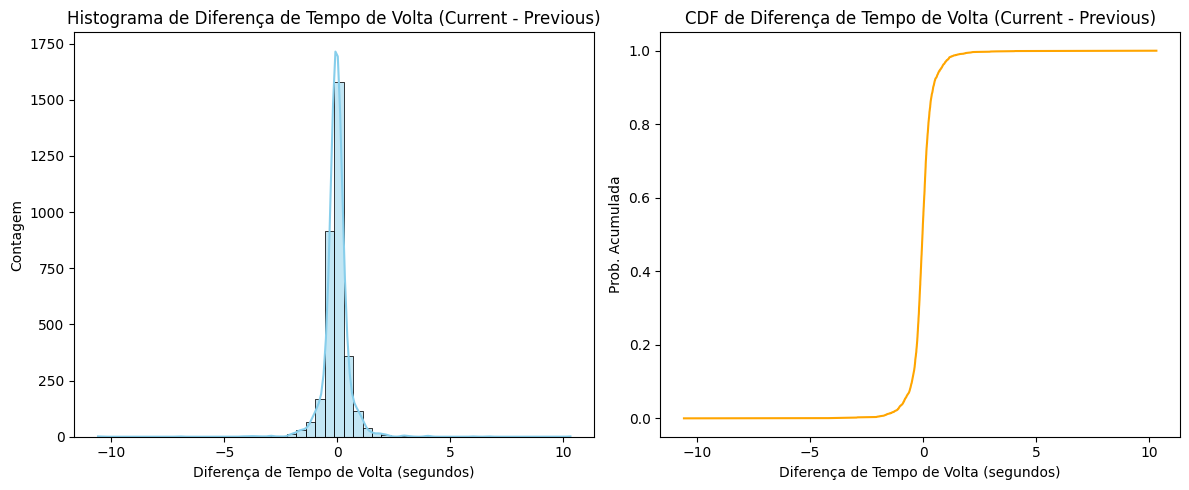

In [5]:
laps_with_weather['laps_diff'] = laps_with_weather['LapTime_seconds'] - laps_with_weather['LapTime_prev']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(laps_with_weather['laps_diff'].dropna(), kde=True, bins=50, color='skyblue')
plt.title('Histograma de Diferença de Tempo de Volta (Current - Previous)')
plt.xlabel('Diferença de Tempo de Volta (segundos)')
plt.ylabel('Contagem')
plt.subplot(1, 2, 2)
sorted_diff = np.sort(laps_with_weather['laps_diff'].dropna())
cdf_vals = np.arange(1, len(sorted_diff)+1) / len(sorted_diff)
plt.plot(sorted_diff, cdf_vals, color='orange')
plt.title('CDF de Diferença de Tempo de Volta (Current - Previous)')
plt.xlabel('Diferença de Tempo de Volta (segundos)')
plt.ylabel('Prob. Acumulada')
plt.tight_layout()
plt.show()

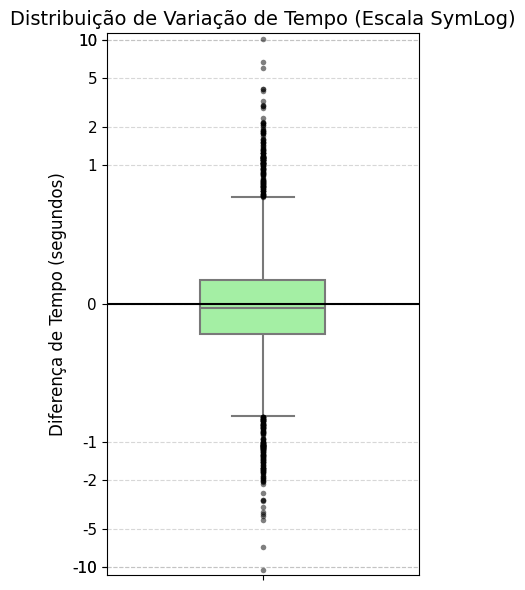

--- CANDIDATOS A CORTE PERFEITO ---
1. Conservador (Top 1%):  [-1.63s, 1.57s]
   (Remove apenas Pit Stops e SCs graves)

2. Padrão Estatístico (IQR): [-0.82s, 0.77s]
   (O mais aceito academicamente para 'outliers')

3. Rigoroso (Top 5%):     [-0.82s, 0.78s]
   (Deixa apenas voltas muito consistentes)


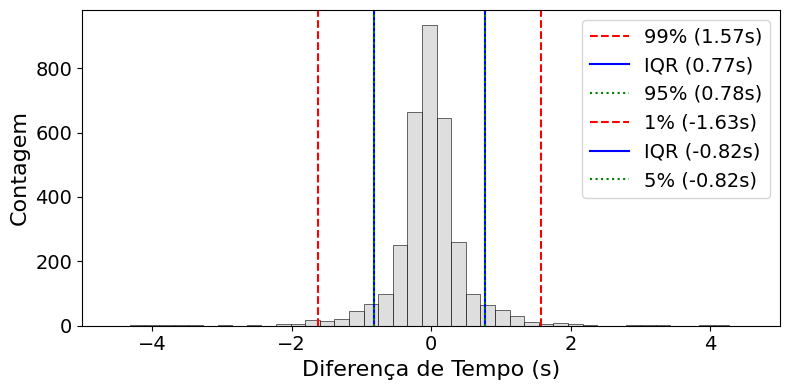

In [6]:
diff_data = laps_with_weather['laps_diff'].dropna()

plt.figure(figsize=(4, 6))

sns.boxplot(
    y=diff_data,
    color='#98FB98',
    width=0.4,
    linewidth=1.5,
    flierprops={"marker": "o", "markerfacecolor": "black", "markersize": 4, "alpha": 0.5, "markeredgecolor": "none"}
)

plt.yscale('symlog', linthresh=1.0)

custom_ticks = [-100, -50, -20, -10, -5, -2, -1, 0, 1, 2, 5, 10, 20, 50, 100]

min_val, max_val = diff_data.min(), diff_data.max()
visible_ticks = [t for t in custom_ticks if min_val <= t <= max_val]
if min_val < visible_ticks[0]: visible_ticks.insert(0, int(min_val))
if max_val > visible_ticks[-1]: visible_ticks.append(int(max_val))

plt.yticks(visible_ticks, labels=[str(t) for t in visible_ticks], fontsize=11)

plt.ylabel('Diferença de Tempo (segundos)', fontsize=12)
plt.title('Distribuição de Variação de Tempo (Escala SymLog)', fontsize=14)

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')

plt.tight_layout()
plt.show()
p1 = np.percentile(diff_data, 1)
p99 = np.percentile(diff_data, 99)

Q1 = np.percentile(diff_data, 25)
Q3 = np.percentile(diff_data, 75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

p5 = np.percentile(diff_data, 5)
p95 = np.percentile(diff_data, 95)

print("--- CANDIDATOS A CORTE PERFEITO ---")
print(f"1. Conservador (Top 1%):  [{p1:.2f}s, {p99:.2f}s]")
print(f"   (Remove apenas Pit Stops e SCs graves)")
print(f"\n2. Padrão Estatístico (IQR): [{lower_iqr:.2f}s, {upper_iqr:.2f}s]")
print(f"   (O mais aceito academicamente para 'outliers')")
print(f"\n3. Rigoroso (Top 5%):     [{p5:.2f}s, {p95:.2f}s]")
print(f"   (Deixa apenas voltas muito consistentes)")

plt.figure(figsize=(8, 4))
sns.histplot(diff_data, bins=100, kde=False, color='lightgray')

plt.xlim(-5, 5)

plt.axvline(p99, color='red', linestyle='--', label=f'99% ({p99:.2f}s)')
plt.axvline(upper_iqr, color='blue', linestyle='-', label=f'IQR ({upper_iqr:.2f}s)')
plt.axvline(p95, color='green', linestyle=':', label=f'95% ({p95:.2f}s)')
plt.axvline(p1, color='red', linestyle='--', label=f'1% ({p1:.2f}s)')
plt.axvline(lower_iqr, color='blue', linestyle='-', label=f'IQR ({lower_iqr:.2f}s)')
plt.axvline(p5, color='green', linestyle=':', label=f'5% ({p5:.2f}s)')

plt.xlabel('Diferença de Tempo (s)', fontsize=16)
plt.ylabel('Contagem', fontsize=16)

plt.tick_params(axis='both', which='major', labelsize=14)

plt.legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
mask_clean = (
    (laps_with_weather['laps_diff'] >= p5) &
    (laps_with_weather['laps_diff'] <= p95)
)

laps_cleaned = laps_with_weather[mask_clean].copy()

print(f"Total original: {len(laps_with_weather)}")
print(f"Total após filtro: {len(laps_cleaned)}")
print(f"Outliers removidos (Voltas lentas/Pit In): {len(laps_with_weather) - len(laps_cleaned)}")

Total original: 3499
Total após filtro: 2994
Outliers removidos (Voltas lentas/Pit In): 505


In [8]:
try:
    stats_df_laps_diff = laps_with_weather.describe(include='all')

    features_interesse = [ 'laps_diff'
    ]

    skewness = laps_with_weather.skew(numeric_only=True)

    kurtosis = laps_with_weather.kurt(numeric_only=True)

    means = laps_with_weather.mean(numeric_only=True)
    stds = laps_with_weather.std(numeric_only=True)

    cv = np.where(means == 0, np.nan, stds / means)

    cv_series = pd.Series(cv, index=means.index)

    stats_df_laps_diff = stats_df_laps_diff[features_interesse]

    stats_df_laps_diff.loc['skewness'] = skewness
    stats_df_laps_diff.loc['kurtosis'] = kurtosis
    stats_df_laps_diff.loc['CV (Coef. Var)'] = cv_series


    print("\n--- Estatísticas ---")
    display(stats_df_laps_diff)


except Exception as e:
    print(f"Ocorreu um erro ao calcular as estatísticas: {e}")
    print("Verifique se o DataFrame 'laps_with_weather' existe e não está vazio.")


--- Estatísticas ---


,laps_diff
count,3328.000000
unique,NaN
top,NaN
freq,NaN
mean,-0.023438
std,0.616594
min,-10.588000
25%,-0.222000
50%,-0.028000
75%,0.174000


---

## 6. Análise Exploratória (EDA) - Distribuições Univariadas

### Objetivo
Compreender o comportamento estatístico individual de cada variável antes de construir relações multivariadas. Isto informa transformações necessárias e valida premissas dos modelos.

### Abordagem Gráfica: Histogramas com KDE
Geramos **Histogramas com Estimativa de Densidade (KDE)** para 10 variáveis numéricas contínuas.

#### Interpretações Esperadas:

1. **Normalidade (`LapTime_seconds`):**
   - Distribuição ~gaussiana indica adequação para modelos lineares
   - Distribuição altamente assimétrica (skewed) sugere necessidade de transformação log

2. **Caudas em Variáveis Temporais (`TyreLife`):**
   - Cauda à direita esperada (distribuição realista de degradação)
   - Alguns valores extremos refletem pit stops de emergência

3. **Multimodalidade em Variáveis Climáticas (`TrackTemp`, `WindDirection`):**
   - Múltiplos picos indicam mudanças drásticas durante a corrida (ex: variação de temperatura em Monza)
   - Justifica uso de técnicas de base radial (RBF) para capturar relações não-lineares


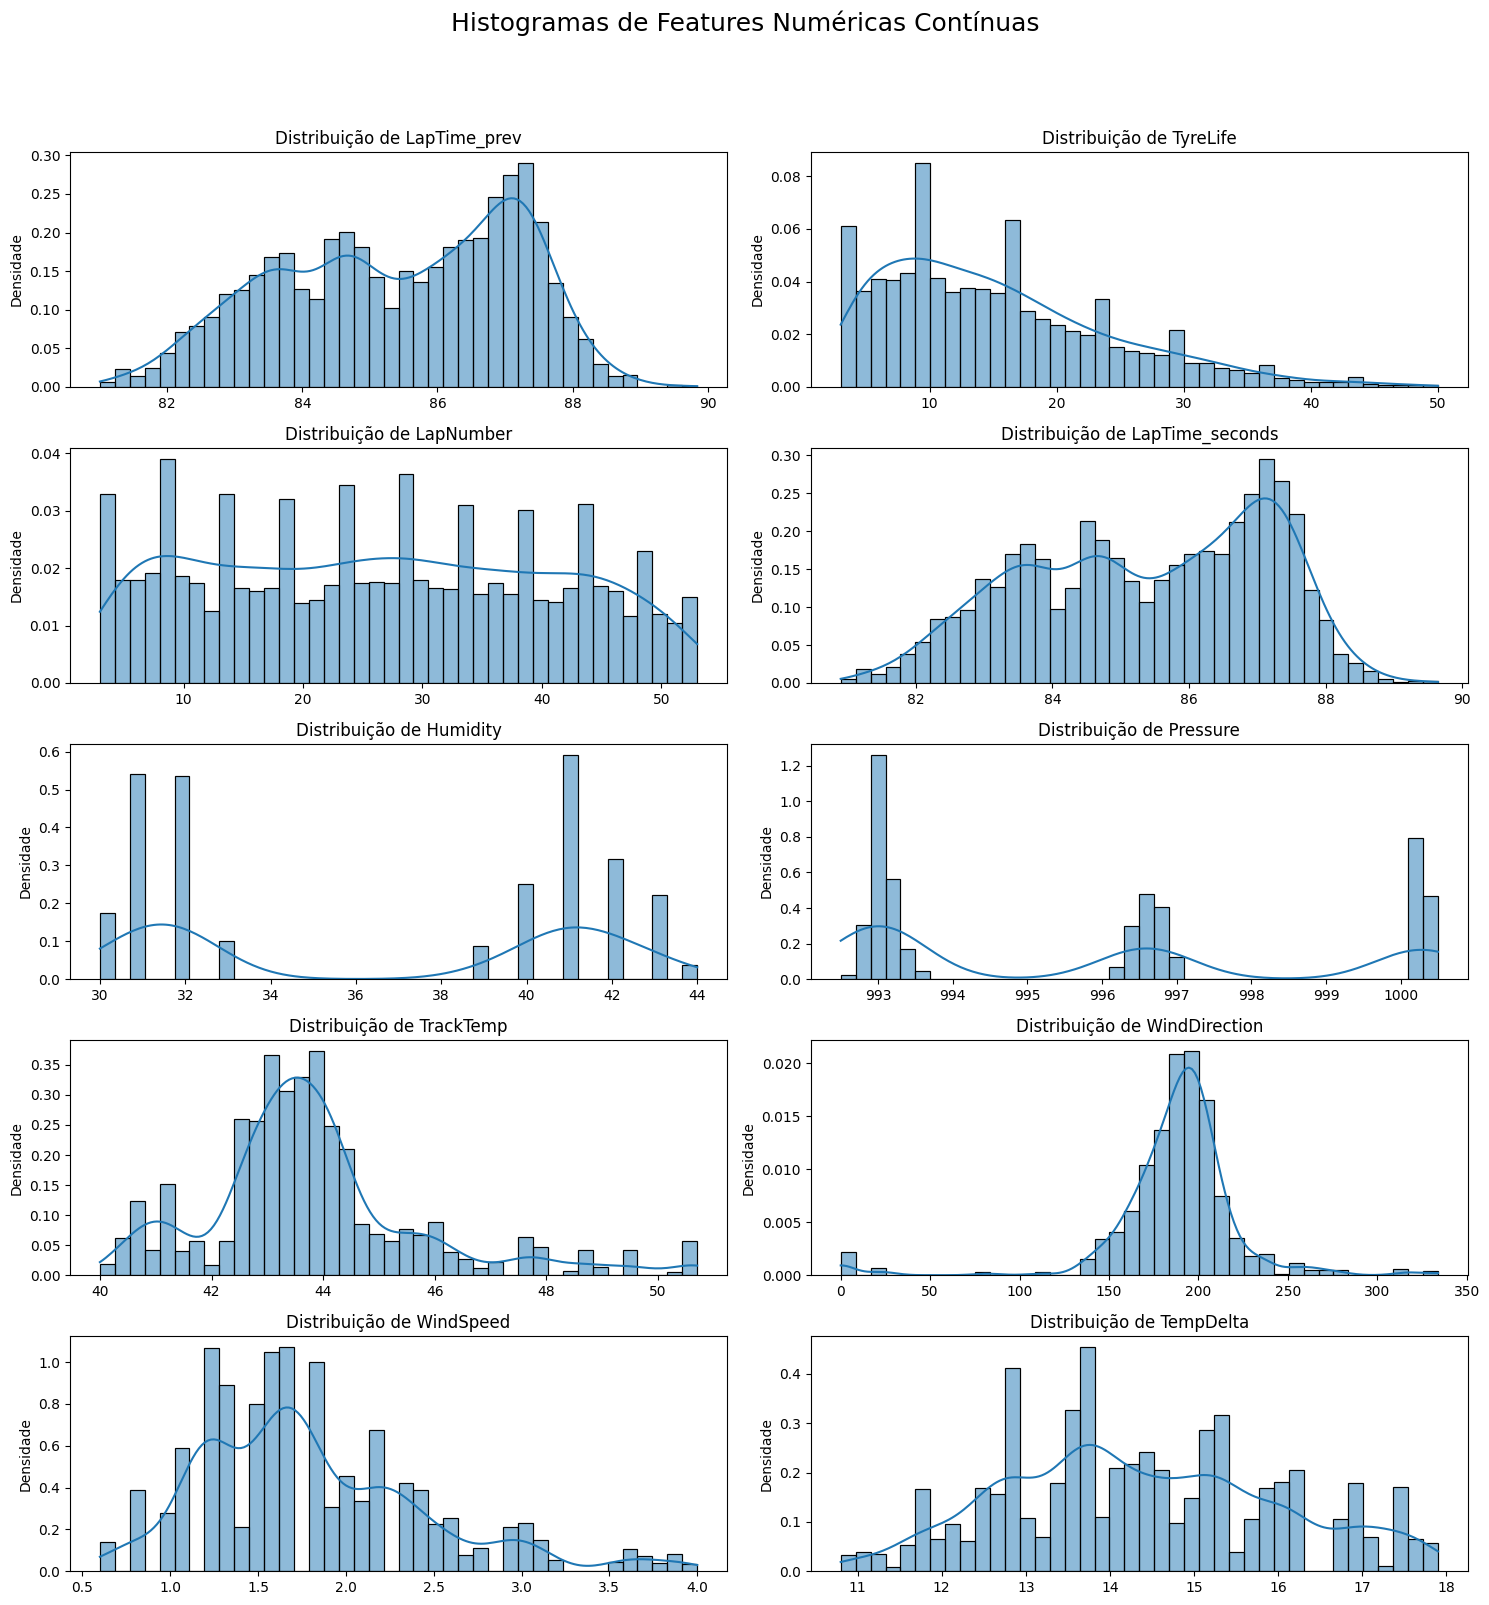

In [9]:
n_rows_cont = 5
n_cols_cont = 2
fig_cont, axes_cont = plt.subplots(n_rows_cont, n_cols_cont, figsize=(15, 16))
flat_axes_cont = axes_cont.flatten()

continuous_cols = [
    'LapTime_prev', 'TyreLife', 'LapNumber', 'LapTime_seconds', 'Humidity',
    'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'TempDelta'
]

num_df = laps_cleaned[continuous_cols].copy()

for i, col in enumerate(continuous_cols):
    ax = flat_axes_cont[i]

    data_to_plot = num_df[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'{col} (Sem Dados)')
        ax.text(0.5, 0.5, 'Sem Dados', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        sns.histplot(data_to_plot, kde=True, ax=ax, bins=40, stat="density")
        ax.set_title(f'Distribuição de {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Densidade')

plt.suptitle('Histogramas de Features Numéricas Contínuas', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

### Comportamento Específico de `TyreLife` por Composto
Histogramas separados por composto de pneu revelam perfis de degradação distintos (C1 > C2 > C5 em Monza).


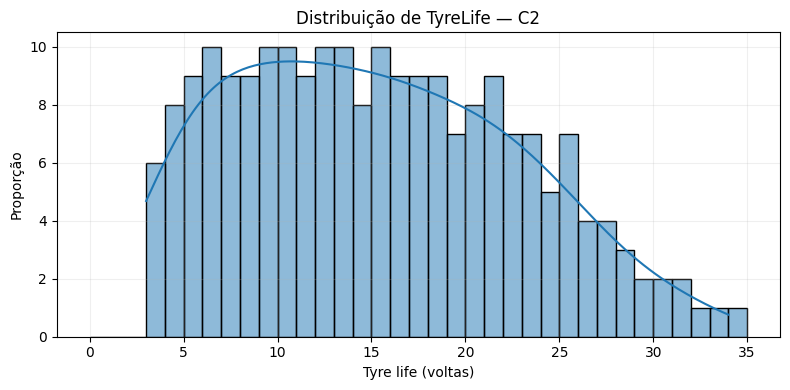

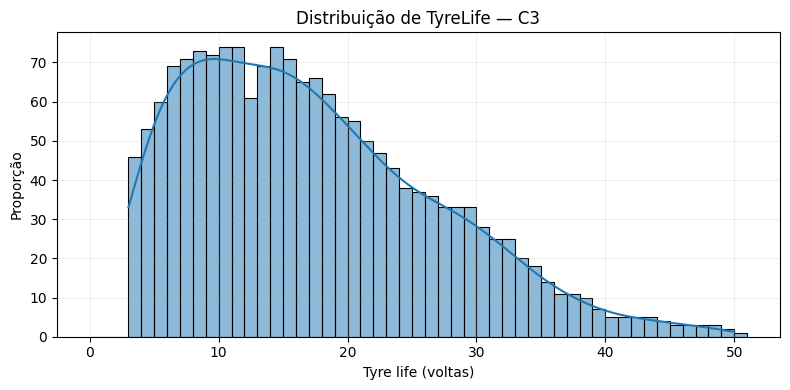

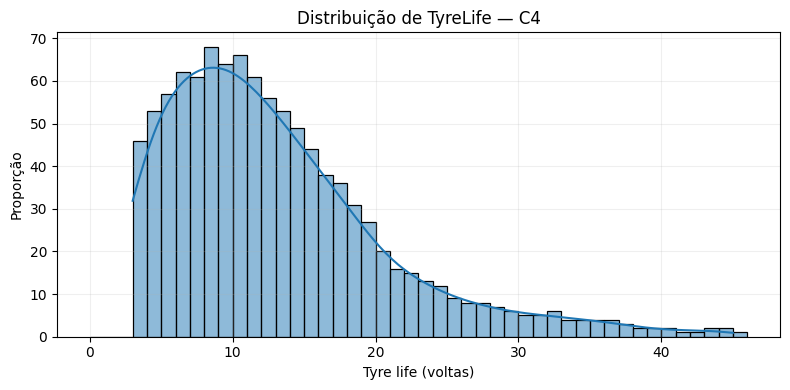

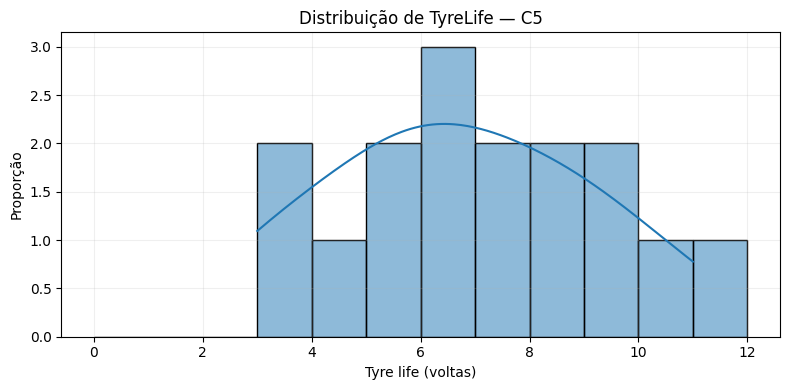

In [10]:
compounds_to_plot = ['C2','C3','C4','C5']

for comp in compounds_to_plot:
    if 'pirelliCompound' in laps_cleaned.columns:
        subset = laps_cleaned[laps_cleaned['pirelliCompound'] == comp]
    elif 'Compound' in laps_cleaned.columns:
        subset = laps_cleaned[laps_cleaned['Compound'] == comp]
    else:
        subset = laps_cleaned[laps_cleaned.get('compound') == comp] if 'compound' in laps_cleaned.columns else laps_cleaned[[]]

    if subset.empty:
        print(f'Nenhum dado disponível para o composto {comp}. Pulando.')
        continue

    tyre_life = subset['TyreLife'].dropna()
    if tyre_life.empty:
        print(f'Nenhum TyreLife válido para {comp}. Pulando.')
        continue

    max_life = int(tyre_life.max()) if pd.api.types.is_numeric_dtype(tyre_life) else tyre_life.max()
    bins = range(0, max(2, max_life + 2)) if isinstance(max_life, int) else 10

    plt.figure(figsize=(8,4))
    sns.histplot(tyre_life, bins=bins, kde=True, color='C0', stat='count')
    plt.title(f'Distribuição de TyreLife — {comp}')
    plt.xlabel('Tyre life (voltas)')
    plt.ylabel('Proporção')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

### Função de Distribuição Acumulada (CDF)

Complementando os histogramas, a **CDF empírica** oferece uma leitura probabilística sem o viés de binagem (agrupamento das barras):

$$F(x) = P(X \leq x) = \frac{\text{número de observações } \leq x}{n}$$

**Uso:** Quantificar *outliers* com precisão e detectar assimetrias em cauda.


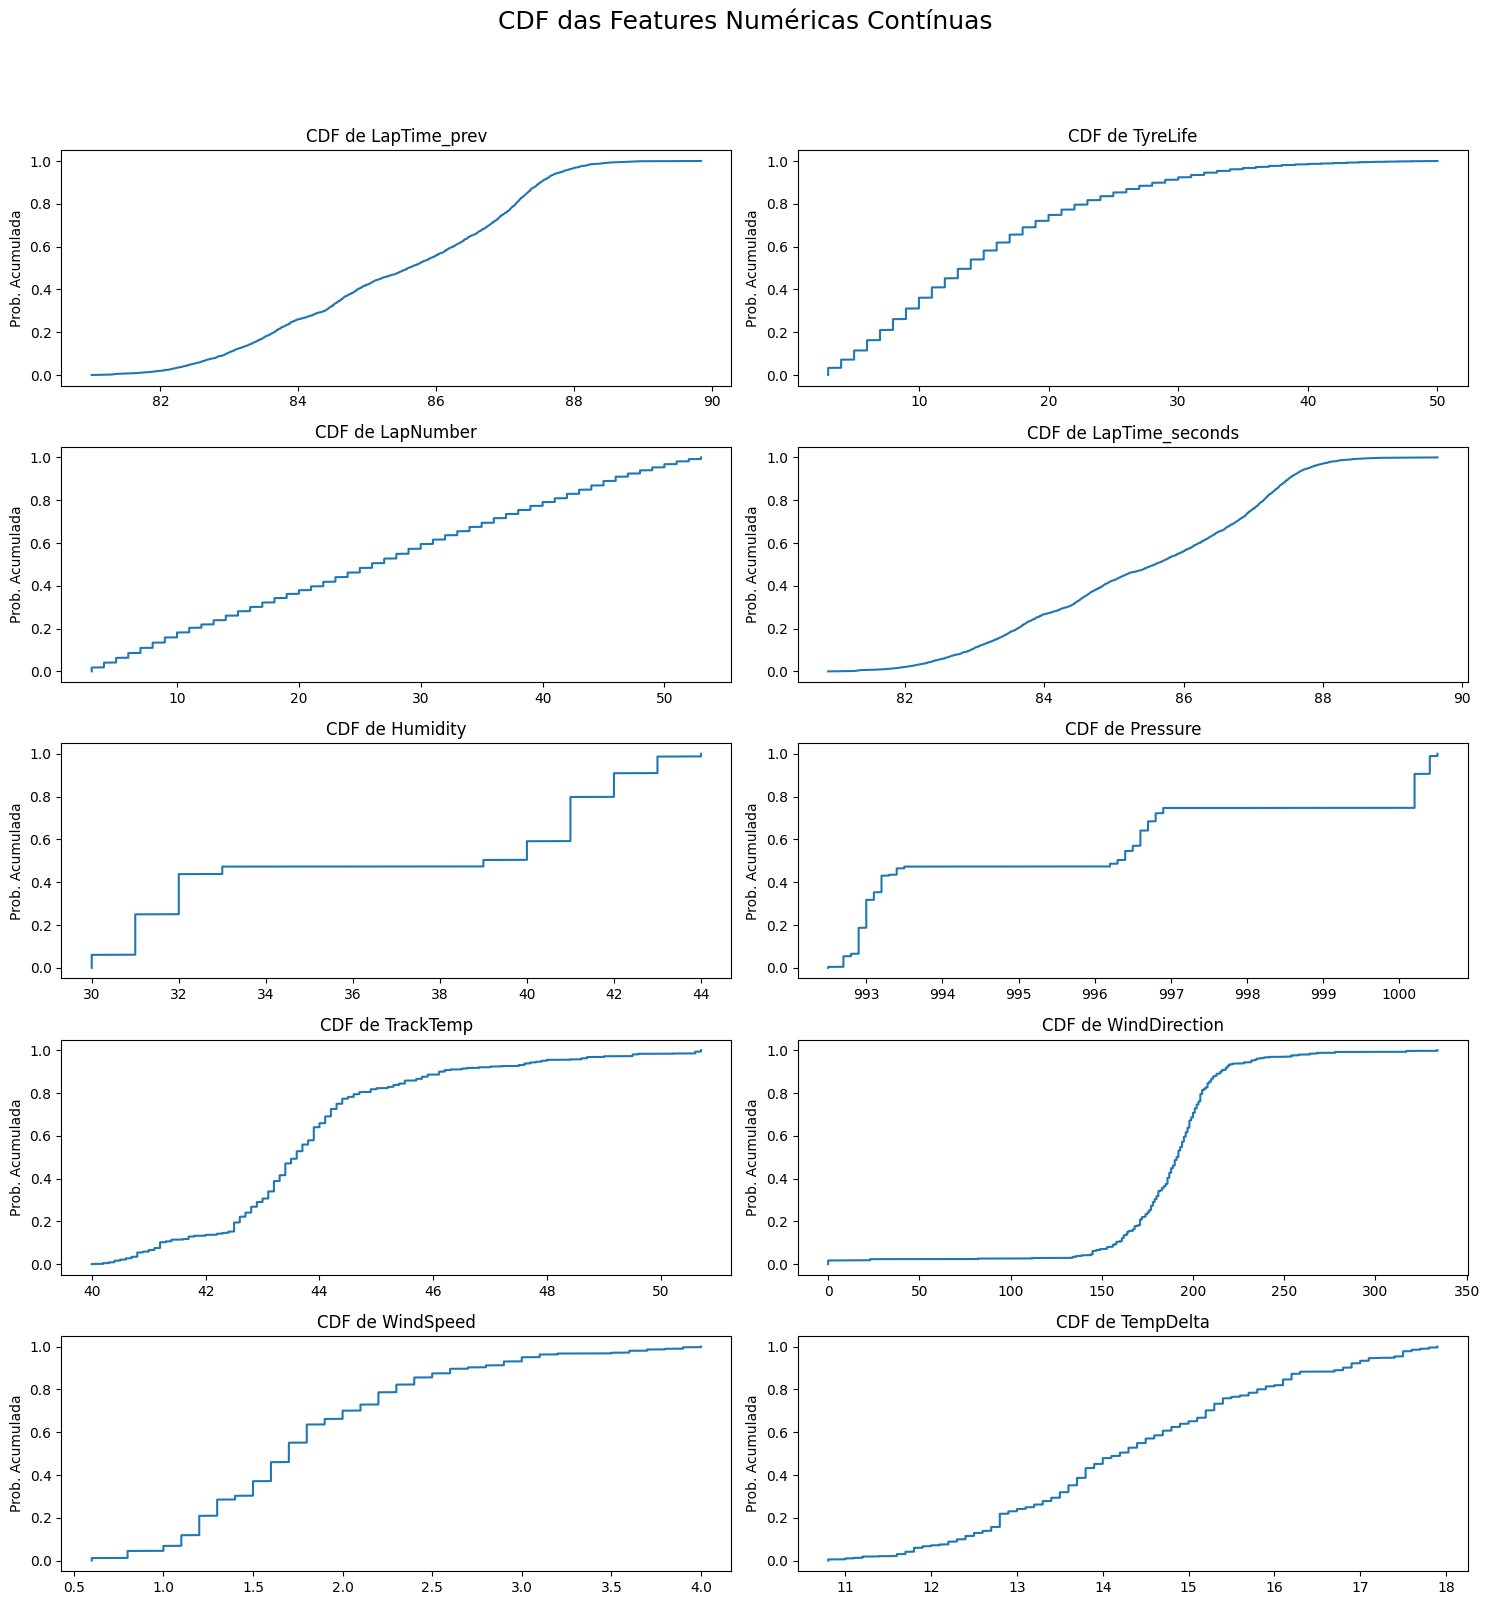

In [11]:
fig_cdf, axes_cdf = plt.subplots(n_rows_cont, n_cols_cont, figsize=(15, 16))
flat_axes_cdf = axes_cdf.flatten()


for i, col in enumerate(continuous_cols):
    ax = flat_axes_cdf[i]

    data_to_plot = num_df[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'{col} (Sem Dados)')
        ax.text(0.5, 0.5, 'Sem Dados', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:

        sorted_vals = np.sort(data_to_plot)
        cdf_vals = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

        ax.plot(sorted_vals, cdf_vals)
        ax.set_title(f'CDF de {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Prob. Acumulada')

plt.suptitle('CDF das Features Numéricas Contínuas', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

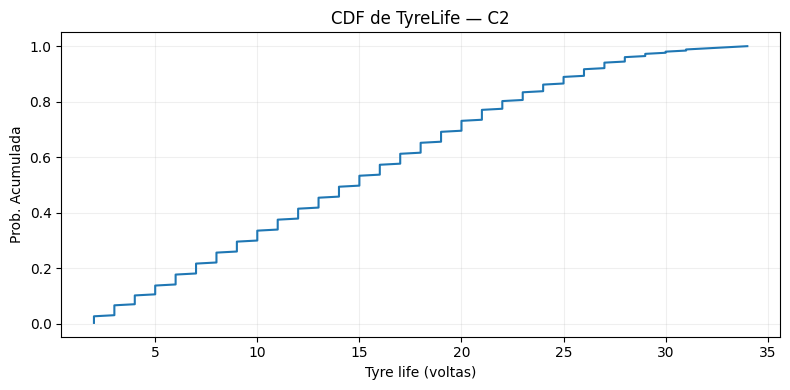

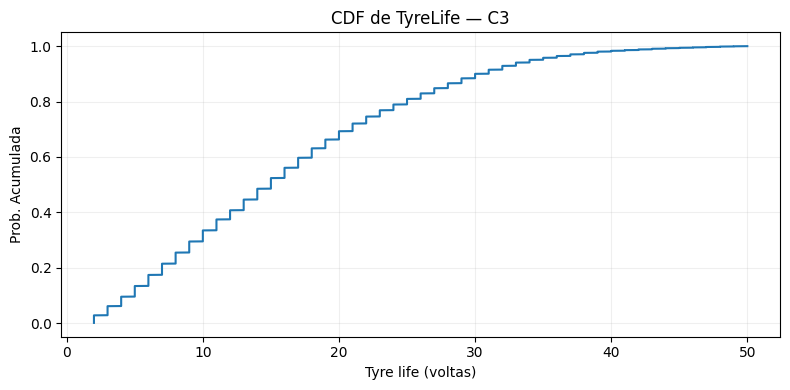

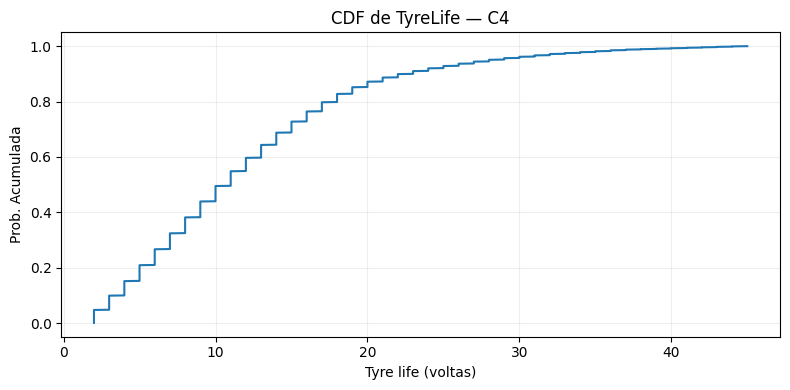

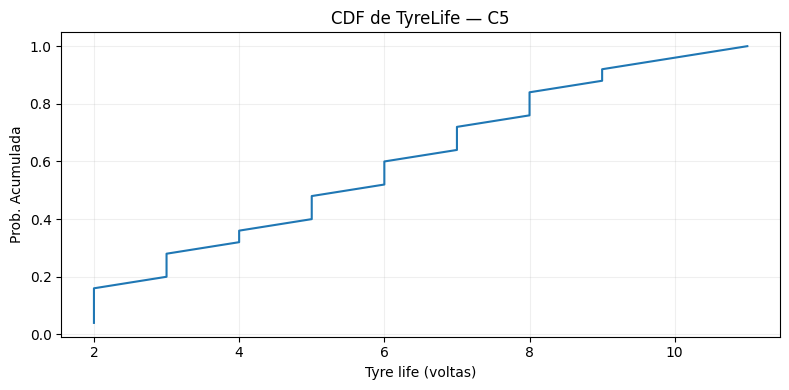

In [12]:
for comp in compounds_to_plot:
    if 'pirelliCompound' in laps_with_weather.columns:
        subset = laps_with_weather[laps_with_weather['pirelliCompound'] == comp]
    elif 'Compound' in laps_with_weather.columns:
        subset = laps_with_weather[laps_with_weather['Compound'] == comp]
    else:
        subset = laps_with_weather[laps_with_weather.get('compound') == comp] if 'compound' in laps_with_weather.columns else laps_with_weather[[]]

    if subset.empty:
        print(f'Nenhum dado disponível para o composto {comp}. Pulando.')
        continue

    tyre_life = subset['TyreLife'].dropna()
    if tyre_life.empty:
        print(f'Nenhum TyreLife válido para {comp}. Pulando.')
        continue

    sorted_vals = np.sort(tyre_life)
    cdf_vals = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

    plt.figure(figsize=(8,4))
    plt.plot(sorted_vals, cdf_vals, color='C0')
    plt.title(f'CDF de TyreLife — {comp}')
    plt.xlabel('Tyre life (voltas)')
    plt.ylabel('Prob. Acumulada')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

---

## 7. Análise de Frequência - Variáveis Categóricas

### Objetivo
Identificar desequilíbrios de classe (imbalance) que afetam generalização do modelo, usando **Countplots** para quatro dimensões.

#### 1. **Pilotos (`Driver`)**
- **Interpretação:** Barras pequenas indicam pilotos com DNF (Did Not Finish) ou entrada tardia na season → menos dados de treinamento
- **Impacto:** Modelos podem overfitar em pilotos com muitos dados

#### 2. **Equipes (`Team`)**
- **Interpretação:** Distribuição revela dominância (ex: Red Bull >> Sauber)
- **Impacto:** Necessidade de técnicas de regularização para evitar viés em equipes grandes

#### 3. **Compostos de Pneus (`pirelliCompound`)**
- **Interpretação:** Meta-estratégia do circuito (ex: Itália: C5 >> C1)
- **Impacto:** Valida se modelo aprende performance de pneus relevantes; pneus raros têm menos exemplos

#### 4. **Ano (`Year`)**
- **Interpretação:** Trend temporal de regulamentações
- **Impacto:** Permite detecção de quebras estruturais (ex: mudança de regulamento em 2022)


Gerando gráficos de frequência (Countplots) para variáveis categóricas...


C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\3532200431.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")


C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\3532200431.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\3532200431.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\3532200431.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\3532200431.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

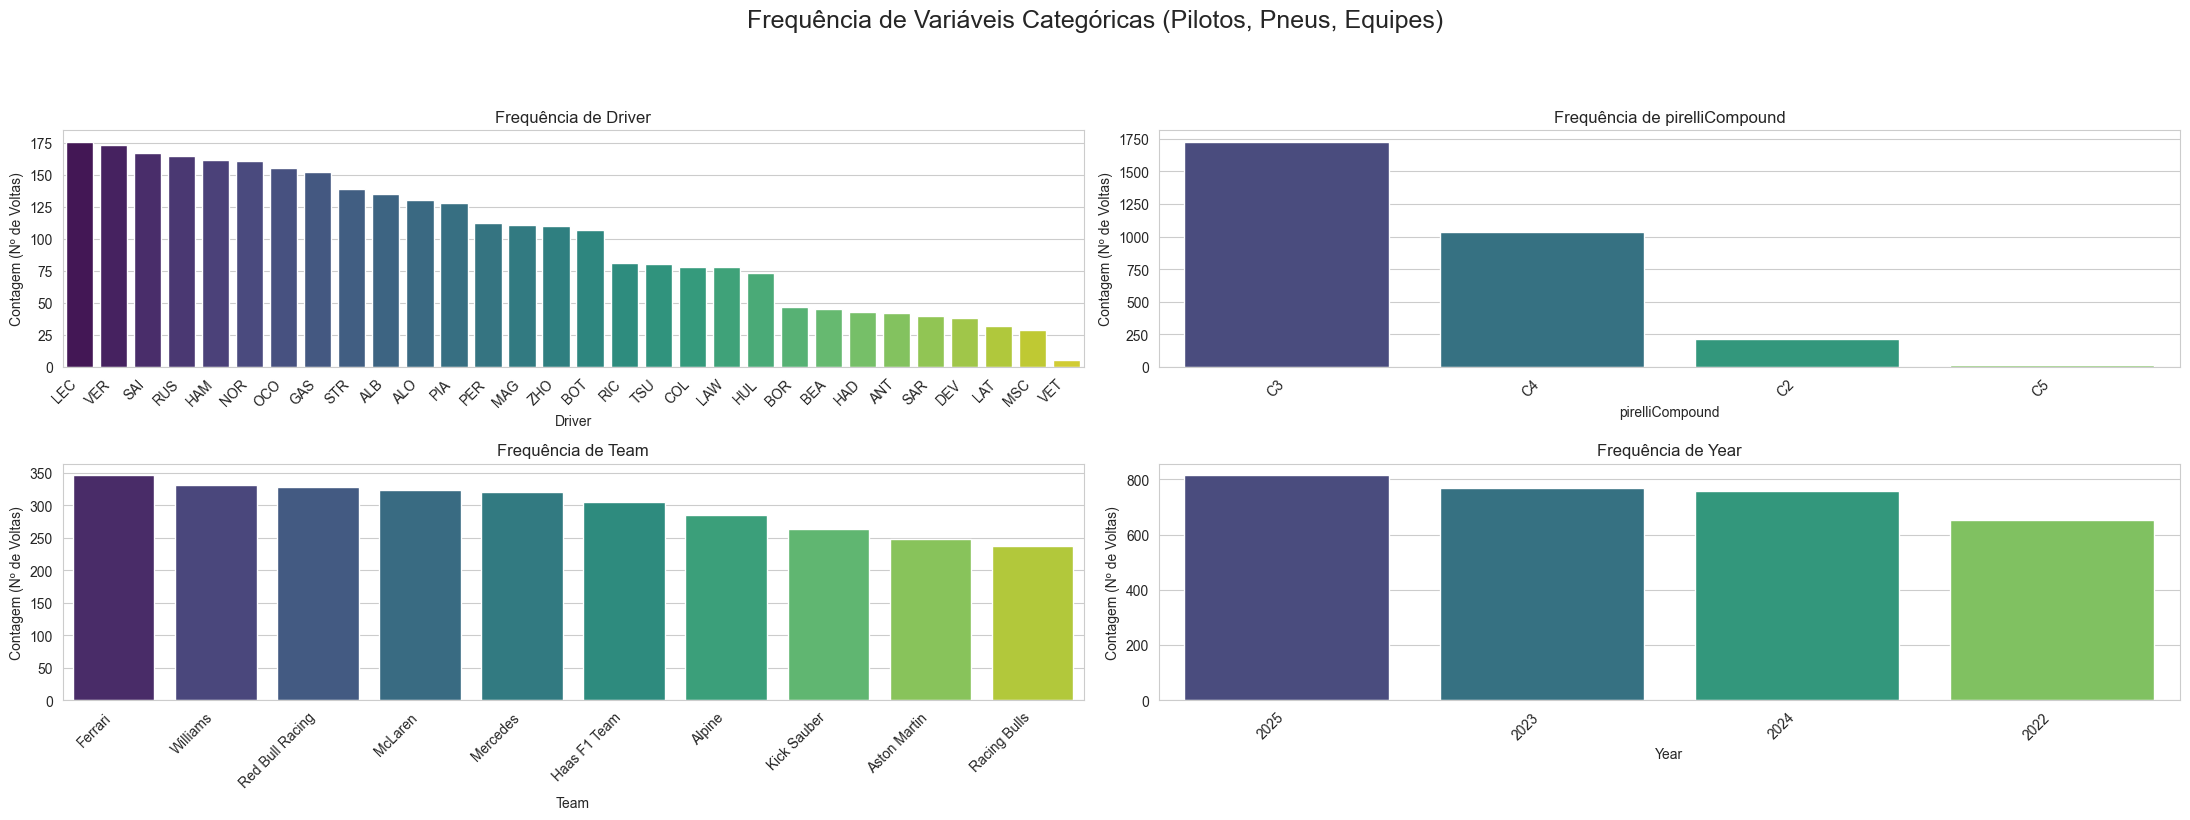

In [13]:
cat_cols = ['Driver', 'pirelliCompound', 'Team', 'Year']

print("Gerando gráficos de frequência (Countplots) para variáveis categóricas...")

sns.set_style("whitegrid")

n_rows_cat = 2
n_cols_cat = 2
fig_cat, axes_cat = plt.subplots(n_rows_cat, n_cols_cat, figsize=(22, 8))

flat_axes_cat = axes_cat.flatten()

for i, col in enumerate(cat_cols):
    ax = flat_axes_cat[i]

    data_to_plot = laps_cleaned[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'Frequência de {col} (Sem Dados)')
        ax.text(0.5, 0.5, 'Sem Dados', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        bar_order = data_to_plot.value_counts().index

        sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")

        ax.set_title(f'Frequência de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Contagem (Nº de Voltas)')

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Frequência de Variáveis Categóricas (Pilotos, Pneus, Equipes)', fontsize=18, y=1.05)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

plt.show()

### Nota sobre `TrackStatus`
`TrackStatus` é um código composto que descreve a condição de pista (1=Green, 2=Yellow, 4=SafetyCar, 5=Red, etc.). Como filtramos apenas voltas com `IsAccurate=True`, quase exclusivamente temos `TrackStatus=1`. Portanto, não incluímos sua análise aqui (seria redundante pos-filtragem).


---

## 8. Diagnóstico de Dispersão e Outliers Via Boxplots

### Interpretação
Boxplots mostram **a distribuição via quartis**, permitindo visualização de outliers estatísticos:

- **Caixa = IQR:** Intervalo interquartil (50% central dos dados)
  - Caixa grande = alta variabilidade
  - Caixa pequena = consistência

- **Bigodes = [Q1-1.5×IQR, Q3+1.5×IQR]:** Limites de normalidade
- **Pontos isolados:** Outliers estatísticos (além de 1.5×IQR)

### Interpretações Específicas para F1

- **`TyreLife`:** Distribuição uniforme esperada; ausência de outliers indica dados limpos

- **`LapTime_seconds`:** Pontos acima do limite superior refletem voltas lentas remanescentes (apesar do `IsAccurate`)

- **Variáveis climáticas:** Pontos isolados podem indicar falhas de sensor ou mudança climática abrupta (ex: alteração de temperatura em Monza)


C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\1742469271.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\1742469271.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\1742469271.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\1742469271.py:18: FutureWarni

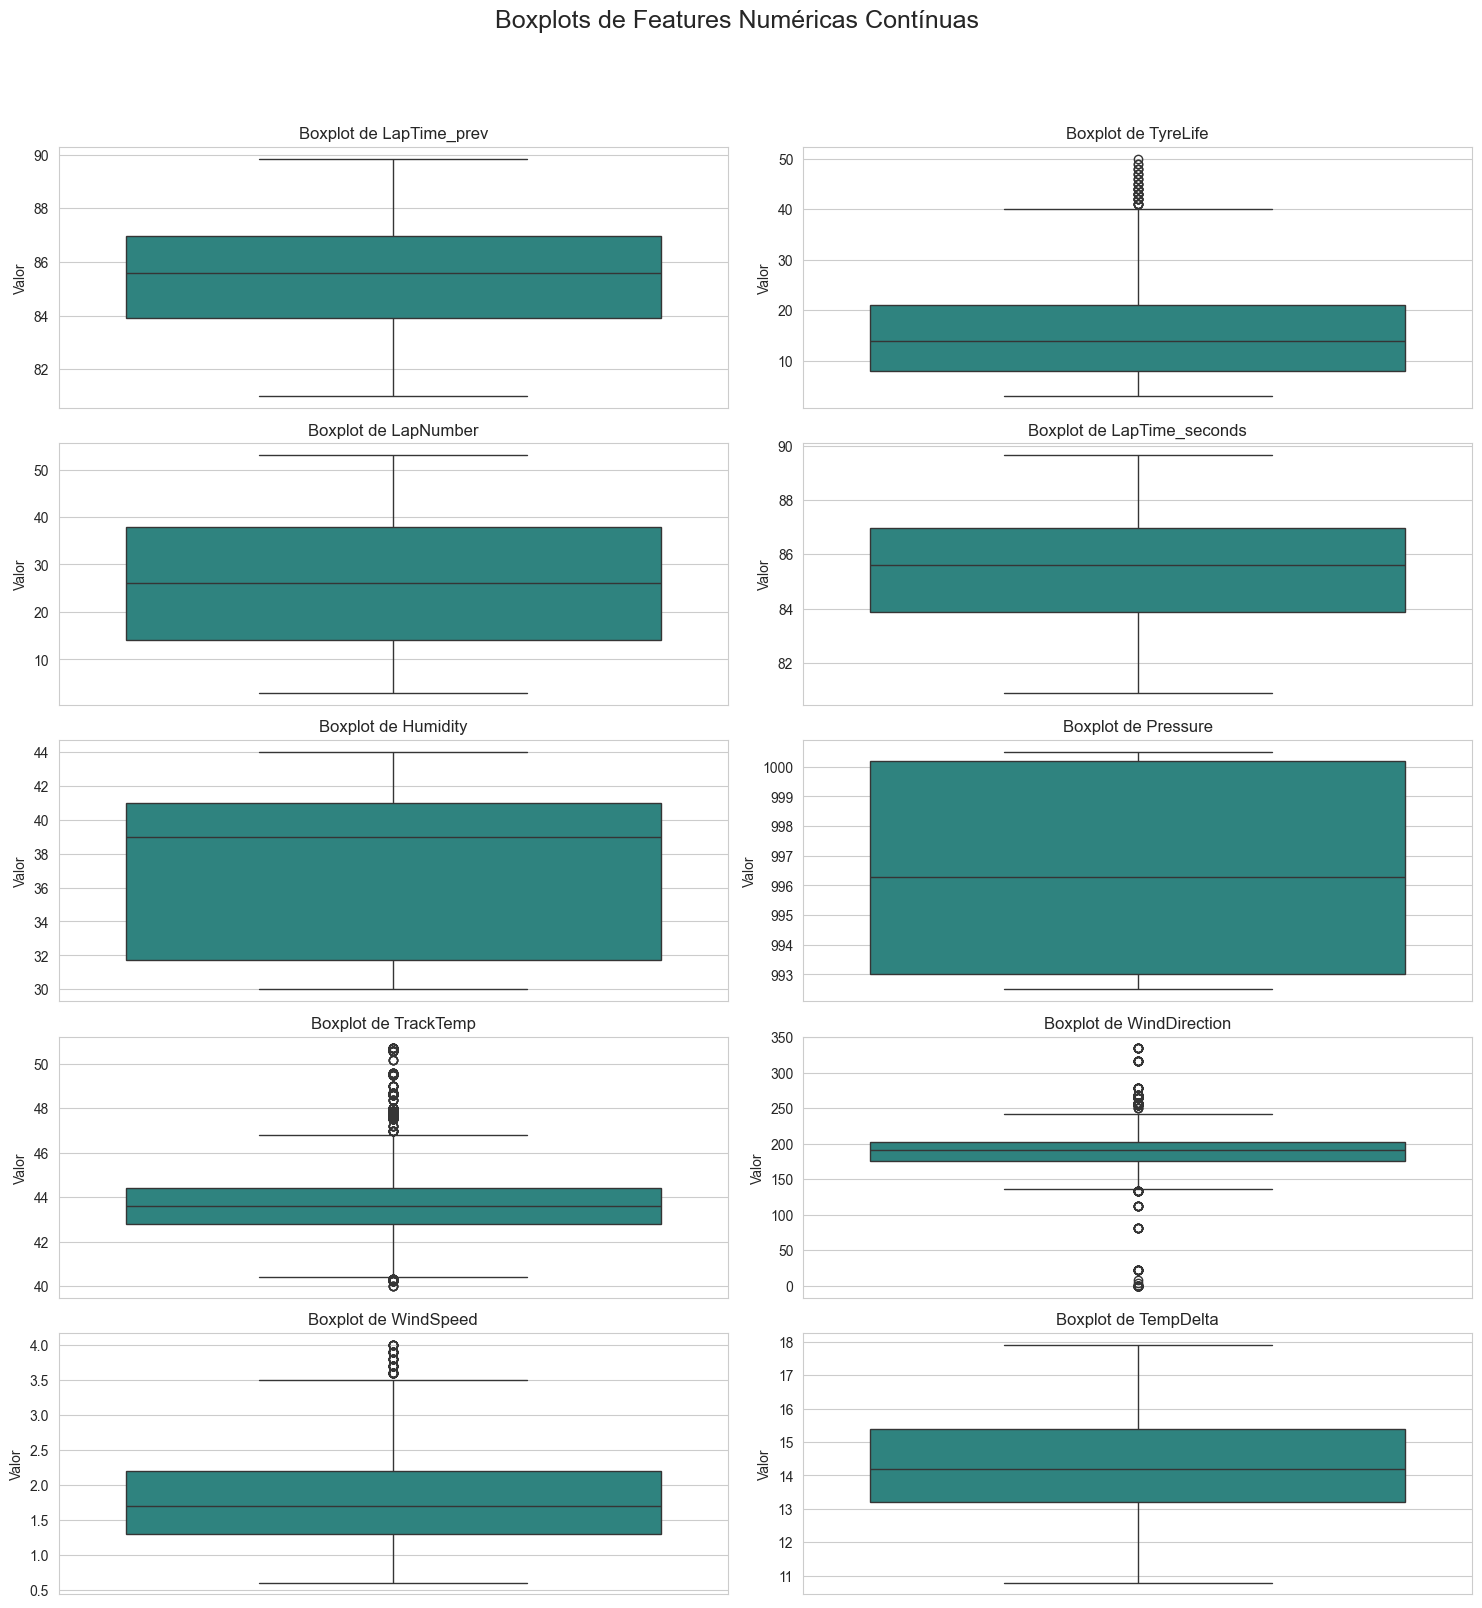

In [14]:
n_rows = 5
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 16))
flat_axes = axes.flatten()

sns.set_style("whitegrid")

for i, col in enumerate(continuous_cols):
    ax = flat_axes[i]

    data_to_plot = laps_cleaned[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'Boxplot de {col} (Sem Dados)')
        ax.text(0.5, 0.5, 'Sem Dados', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
        ax.set_title(f'Boxplot de {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Valor')

plt.suptitle('Boxplots de Features Numéricas Contínuas', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

---

## 9. Estatísticas Descritivas e Momentos de Distribuição

### Métricas Calculadas

1. **Skewness (Assimetria):**
   $$\text{Skewness} = E\left[\left(\frac{X-\mu}{\sigma}\right)^3\right]$$
   - Mede desvio da simetria normal
   - **Skewness > 1:** Cauda direita (right-skewed)
   - **Skewness < -1:** Cauda esquerda (left-skewed)
   - Indica necessidade de transformação (log, box-cox)

2. **Kurtosis (Curtose):**
   - Mede "peso" das caudas (propensão a outliers)
   - Alto kurtosis → caudas pesadas → outliers frequentes

3. **Coeficiente de Variação (CV):**
   $$CV = \frac{\sigma}{\mu}$$
   - Permite comparação entre variáveis de escalas diferentes
   - Medida adimensional de dispersão relativa

**Tabela gerada:** 10 variáveis × (min, median, max, std, skewness, kurtosis, CV)


In [15]:
try:
    stats_df = laps_cleaned.describe(include='all')

    features_interesse = [
    'LapTime_prev', 'TyreLife', 'LapNumber', 'LapTime_seconds',
    'Humidity', 'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'TempDelta'
    ]

    skewness = laps_cleaned.skew(numeric_only=True)

    kurtosis = laps_cleaned.kurt(numeric_only=True)

    means = laps_cleaned.mean(numeric_only=True)
    stds = laps_cleaned.std(numeric_only=True)

    cv = np.where(means == 0, np.nan, stds / means)

    cv_series = pd.Series(cv, index=means.index)

    stats_df = stats_df[features_interesse]

    stats_df.loc['skewness'] = skewness
    stats_df.loc['kurtosis'] = kurtosis
    stats_df.loc['CV (Coef. Var)'] = cv_series


    print("\n--- Estatísticas ---")
    display(stats_df)


except Exception as e:
    print(f"Ocorreu um erro ao calcular as estatísticas: {e}")
    print("Verifique se o DataFrame 'laps_with_weather' existe e não está vazio.")


--- Estatísticas ---


,LapTime_prev,TyreLife,LapNumber,LapTime_seconds,Humidity,Pressure,TrackTemp,WindDirection,WindSpeed,TempDelta
count,2994.000000,2994.000000,2994.000000,2994.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,85.417148,15.383100,26.380094,85.392352,36.621812,995.830403,43.822148,186.941611,1.806577,14.361376
std,1.757787,9.105529,14.178701,1.762679,5.033916,2.993460,1.976423,38.651166,0.655632,1.620946
min,81.003000,3.000000,3.000000,80.901000,30.000000,992.500000,40.000000,0.000000,0.600000,10.800000
25%,83.923750,8.000000,14.000000,83.882000,31.750000,993.000000,42.800000,176.000000,1.300000,13.200000
50%,85.596500,14.000000,26.000000,85.587000,39.000000,996.300000,43.600000,191.000000,1.700000,14.200000
75%,86.970750,21.000000,38.000000,86.962000,41.000000,1000.200000,44.400000,203.000000,2.200000,15.400000


---

## 10. Diagnóstico de Assimetria e Transformação de Variáveis

### Por Quê Normalização?
Modelos lineares (OLS, Ridge) e árvores (XGBoost) performam melhor com:
- Resíduos distribuídos ~Normal
- Variáveis preditoras com distribuição mais simétrica possível
- Sem outliers extremos distorcionando aprendizado

### Critério de Detecção
**Threshold:** $|\text{Skewness}| > 1.0$ (assimetria moderada a severa)


In [16]:
skewed_features = {
    'right_skewed': [],
    'left_skewed': []
}

for feature in stats_df.columns:
    skewness_value = stats_df.at['skewness', feature]
    if pd.notna(skewness_value):
        if skewness_value > 1:
            skewed_features['right_skewed'].append(feature)
        elif skewness_value < -1:
            skewed_features['left_skewed'].append(feature)

print("\n--- Features com Skewness Significativo ---")
print("Right Skewed (skewness > 1):", skewed_features['right_skewed'])
print("Left Skewed (skewness < -1):", skewed_features['left_skewed'])


--- Features com Skewness Significativo ---
Right Skewed (skewness > 1): ['TrackTemp']
Left Skewed (skewness < -1): ['WindDirection']


## 11. Análise de Estratégia: Matriz de Transição de Compostos

Na Fórmula 1, a estratégia de corrida é definida pela sequência de pneus utilizados. Entender as trocas mais comuns (o "Meta-Game") é crucial para prever o comportamento das equipes.

Nesta etapa, construímos uma **Matriz de Transição de Markov** empírica. O objetivo é responder: *"Dado que um piloto está usando o composto X no Stint atual, qual a probabilidade de ele mudar para o composto Y no próximo Stint?"*

A metodologia consiste em:
1.  **Agrupamento por Stint:** Reduzimos o dataset para ter apenas uma linha por jogo de pneus utilizado por cada piloto em cada ano.
2.  **Pareamento Temporal ($t \to t+1$):** Criamos colunas deslocadas (*shifted*) para alinhar o pneu atual (`From_Compound`) com o pneu do próximo stint (`To_Compound`).
3.  **Visualização:** O Heatmap resultante revela as estratégias dominantes.
    * **Bahrein (Sakhir):** Como é uma pista de alta degradação, esperamos ver forte fluxo de pneus mais macios (C3) para pneus mais duros (C1 ou C2). Transições `C3 -> C3` devem ser raras, indicando estratégias agressivas de múltiplas paradas.

Analisando transições de compostos entre stints...

--- Matriz de Contagem de Transição de Stints ---


To_Compound,C2,C3,C4,C5
From_Compound,,,,
C2,0,0,1,0
C3,8,10,21,2
C4,2,44,1,2
C5,0,1,0,0



Gerando heatmap da matriz de transição...


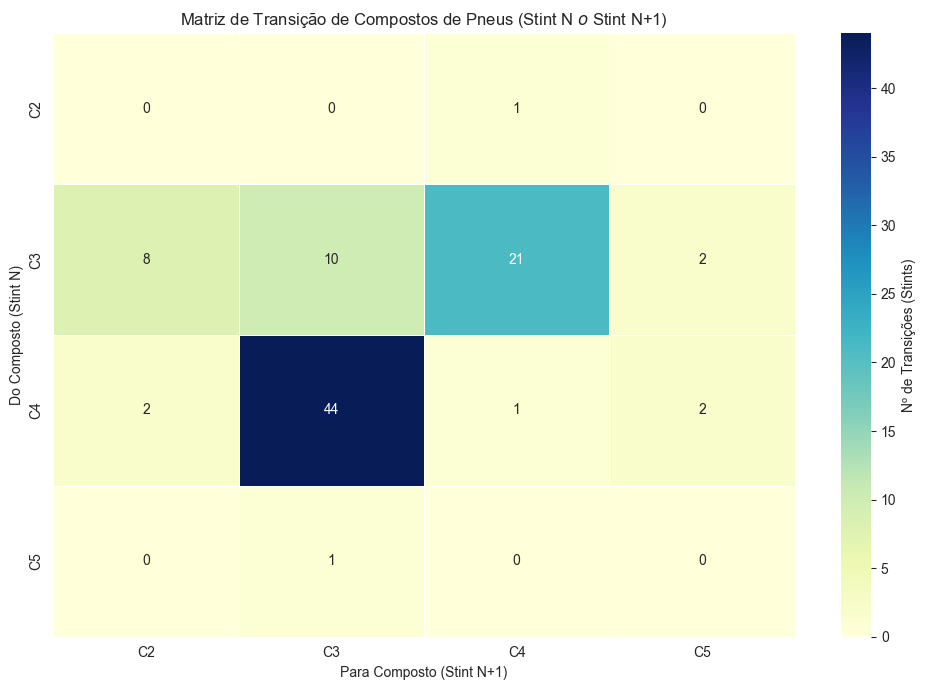

In [17]:
print("Analisando transições de compostos entre stints...")

try:

    stint_df = laps_cleaned[
        ['Year', 'Driver', 'Stint', 'pirelliCompound']
    ].drop_duplicates()

    stint_df = stint_df.sort_values(by=['Year', 'Driver', 'Stint'])

    stint_df['To_Compound'] = stint_df.groupby(['Year', 'Driver'])['pirelliCompound'].shift(-1)

    stint_df = stint_df.rename(columns={'pirelliCompound': 'From_Compound'})

    transitions_df = stint_df.dropna(subset=['To_Compound'])

    if transitions_df.empty:
        print("Não foi possível encontrar dados de transição (múltiplos stints) no DataFrame.")
    else:
        transition_matrix = pd.crosstab(
            transitions_df['From_Compound'],
            transitions_df['To_Compound']
        )

        print("\n--- Matriz de Contagem de Transição de Stints ---")
        display(transition_matrix)

        print("\nGerando heatmap da matriz de transição...")
        plt.figure(figsize=(10, 7))

        ax = sns.heatmap(
            transition_matrix,
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            linewidths=.5,
            cbar_kws={'label': 'Nº de Transições (Stints)'}
        )

        ax.set_title('Matriz de Transição de Compostos de Pneus (Stint N $\to$ Stint N+1)')
        ax.set_xlabel('Para Composto (Stint N+1)')
        ax.set_ylabel('Do Composto (Stint N)')
        plt.tight_layout()
        plt.show()

except NameError:
    print("Erro: O DataFrame 'laps_with_weather_filtered' não foi encontrado.")
    print("Por favor, execute a célula anterior que define este DataFrame.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

## 12. Engenharia de Features: Correção de Assimetria (Log-Transformation)

Com base no diagnóstico de assimetria (*skewness*) realizado anteriormente, aplicamos agora correções matemáticas para normalizar as variáveis que apresentaram forte cauda à direita (`Right Skewed`).

A técnica escolhida foi a **Transformação Logarítmica (`np.log1p`)**, que calcula $ln(1 + x)$.
* **Por que `log1p` e não apenas `log`?** Muitas variáveis físicas na F1 (como `Rainfall` ou contadores) podem conter o valor zero. O logaritmo de zero é indefinido ($-\infty$), o que quebraria o modelo. O `log1p` resolve isso deslocando a função.

### Objetivo da Visualização
Os gráficos abaixo comparam a distribuição **Original (Vermelho)** com a **Transformada (Verde)**.
* **O que esperamos ver:** A distribuição verde deve se aproximar de uma curva em sino (Gaussiana/Normal), e o valor de *skewness* deve cair drasticamente (aproximando-se de zero). Isso facilita o aprendizado para modelos lineares e melhora a estabilidade para modelos baseados em gradiente (como o XGBoost).

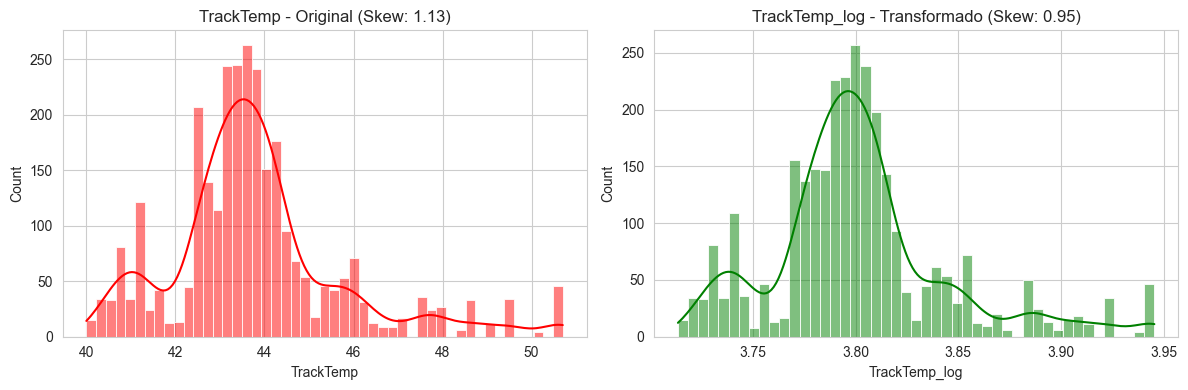

In [18]:
right_skewed_cols = skewed_features['right_skewed']

for col in right_skewed_cols:
    if col in laps_cleaned.columns:
        laps_cleaned[f'{col}_log'] = np.log1p(laps_cleaned[col])

for col in right_skewed_cols:
    if col in laps_cleaned.columns:
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(laps_cleaned[col], kde=True, ax=ax[0], color='red')
        ax[0].set_title(f'{col} - Original (Skew: {laps_cleaned[col].skew():.2f})')

        sns.histplot(laps_cleaned[f'{col}_log'], kde=True, ax=ax[1], color='green')
        ax[1].set_title(f'{col}_log - Transformado (Skew: {laps_cleaned[f"{col}_log"].skew():.2f})')

        plt.tight_layout()
        plt.show()

## 13. Engenharia de Features: Tratamento de Não-Linearidade Climática (RBF)

Variáveis climáticas na Fórmula 1, como a **Temperatura da Pista (`TrackTemp`)**, raramente possuem uma relação linear simples com o tempo de volta. Existe uma "Janela de Operação Ideal":
* **Muito Frio:** Pneu não aquece, falta aderência $\to$ Tempo sobe.
* **Ideal (Mediana):** Aderência máxima $\to$ Tempo desce.
* **Muito Quente:** Pneu superaquece (blistering), perde performance $\to$ Tempo sobe.

Um modelo linear tradicional interpretaria `TrackTemp` apenas como "quanto maior, pior" (ou melhor), falhando em capturar esse ponto ótimo central. Para resolver isso, aplicamos uma **Transformação de Base Radial (RBF - Radial Basis Function)** centrada na mediana histórica de cada variável.

A fórmula aplicada é:
$$RBF(x) = e^{-\gamma \cdot (x - \mu)^2}$$

Onde:
* $\mu$ (mu) é a **Mediana** da variável (representando a condição "típica" ou "ideal" da pista).
* $\gamma$ (gamma) controla a sensibilidade da curva (definido como 0.1).

**Interpretação da Nova Feature (`_RBF_Median`):**
* **Valor $\approx$ 1.0:** Indica que a condição climática está próxima da mediana histórica (condição normal/ideal).
* **Valor $\to$ 0.0:** Indica uma condição extrema (anomalia), seja ela excessivamente alta ou excessivamente baixa.

Isso permite que o modelo aprenda o impacto da **estabilidade climática** versus **condições extremas**, independentemente da direção do extremo.

Aplicando Transformação RBF (Gamma=0.1) usando a MEDIANA como referência...
Coluna 'TrackTemp': Mediana = 43.60
Coluna 'Humidity': Mediana = 39.00
Coluna 'Pressure': Mediana = 996.30
Coluna 'WindSpeed': Mediana = 1.70
Coluna 'WindDirection': Mediana = 191.00
Coluna 'TempDelta': Mediana = 14.20


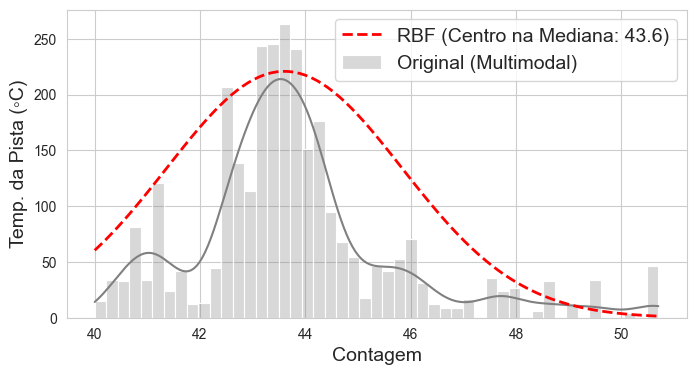


Novas Features Criadas: ['TrackTemp_RBF_Median', 'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median', 'WindDirection_RBF_Median', 'TempDelta_RBF_Median']


In [19]:
weather_cols = ['TrackTemp', 'Humidity', 'Pressure', 'WindSpeed', 'WindDirection', 'TempDelta']
gamma_value = 0.1

print(f"Aplicando Transformação RBF (Gamma={gamma_value}) usando a MEDIANA como referência...")

for col in weather_cols:
    if col in laps_cleaned.columns:
        median_val = laps_cleaned[col].median()

        print(f"Coluna '{col}': Mediana = {median_val:.2f}")

        col_name = f"{col}_RBF_Median"

        squared_dist = (laps_cleaned[col] - median_val) ** 2
        laps_cleaned[col_name] = np.exp(-gamma_value * squared_dist)

        laps_cleaned[col_name] = laps_cleaned[col_name].fillna(0)

col_exemplo = 'TrackTemp'
if col_exemplo in weather_cols:
    col_transformed = f"{col_exemplo}_RBF_Median"
    median_exemplo = laps_cleaned[col_exemplo].median()

    plt.figure(figsize=(8, 4))
    ax1 = plt.gca()

    sns.histplot(laps_cleaned[col_exemplo], kde=True, ax=ax1, color='gray', alpha=0.3, label='Original (Multimodal)')

    x_range = np.linspace(laps_cleaned[col_exemplo].min(), laps_cleaned[col_exemplo].max(), 100)
    y_rbf = np.exp(-gamma_value * (x_range - median_exemplo)**2)

    y_max_hist = ax1.get_ylim()[1]
    plt.plot(x_range, y_rbf * y_max_hist * 0.8, color='red',linewidth=2, linestyle='--', label=f'RBF (Centro na Mediana: {median_exemplo:.1f})')

    plt.xlabel('Contagem', fontsize=14)
    plt.ylabel('Temp. da Pista (◦C)', fontsize=14)
    plt.legend(fontsize=14)
    plt.show()

new_features = [c for c in laps_cleaned.columns if '_RBF_Median' in c]
print(f"\nNovas Features Criadas: {new_features}")

## 14. Análise Multivariada: Matriz de Correlação de Pearson

Após a engenharia de features, é fundamental investigar as relações lineares entre as variáveis preditoras e a variável alvo (`LapTime_seconds`). Nesta etapa, construímos uma **Matriz de Correlação Híbrida**, combinando:

1.  **Variáveis Físicas Contínuas:** Incluindo as novas transformações RBF e vetores de vento (`Wind_Sin`/`Wind_Cos`).
2.  **Variáveis Categóricas (One-Hot Encoded):** Transformamos Equipes, Compostos de Pneus e Anos em colunas binárias para medir o impacto de cada categoria na performance.

### O que observar neste Mapa de Calor:
* **Autocorrelação:** Espera-se uma correlação muito forte ($>0.8$) entre `LapTime_prev` e `LapTime_seconds`, confirmando a inércia do desempenho.
* **Física dos Pneus:** Uma correlação **positiva** entre `TyreLife` e `LapTime_seconds` valida a hipótese de que pneus mais velhos geram tempos mais altos (lentos).
* **Hierarquia de Equipes:** Correlações negativas fortes em equipes como `Team_Red Bull Racing` indicam que pertencer a essa equipe reduz o tempo de volta, enquanto correlações positivas em equipes do fundo do grid indicam o oposto.
* **Clima:** As features `_RBF_Median` devem mostrar como o desvio das condições ideais impacta o tempo.

*Nota: Utilizamos uma máscara triangular para evitar redundância visual, focando apenas nas correlações únicas.*

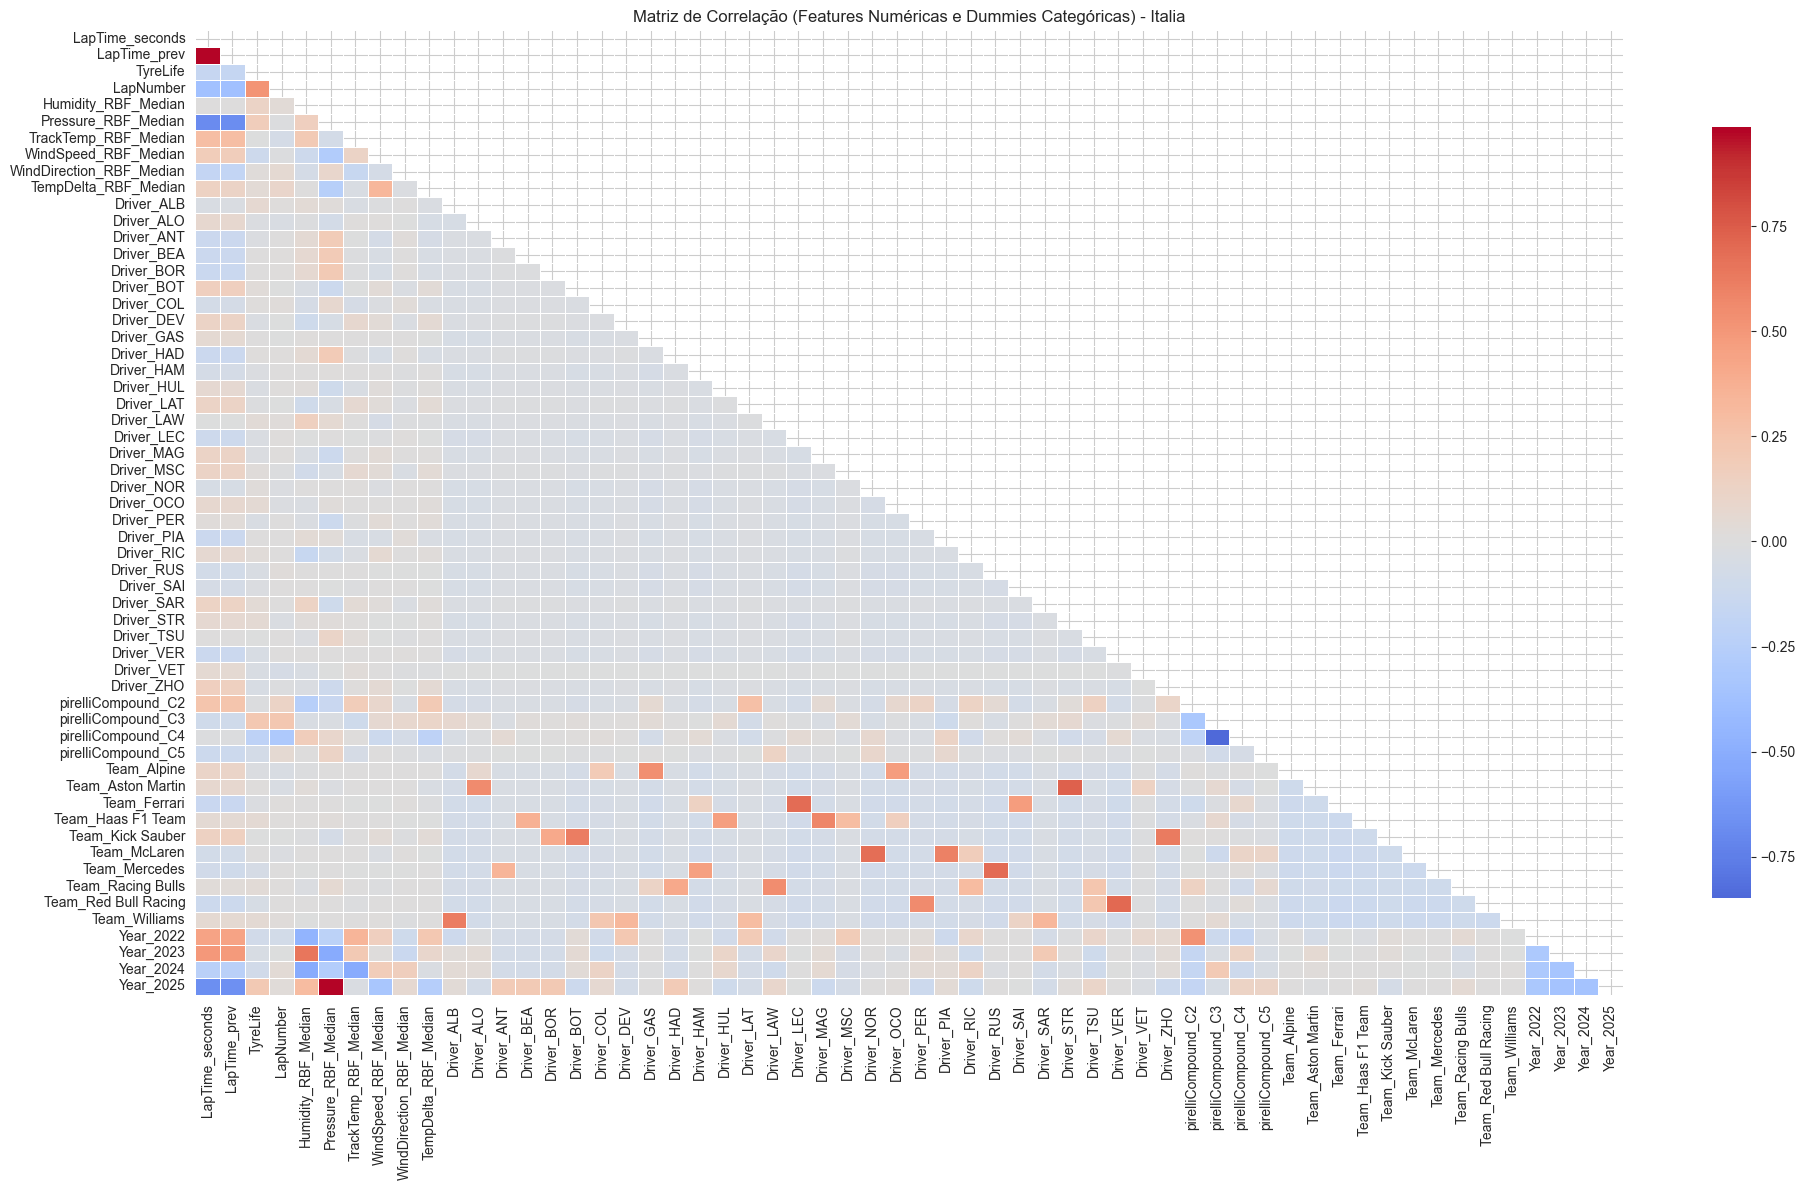

In [20]:
num_cols = ['LapTime_seconds', 'LapTime_prev', 'TyreLife', 'LapNumber',
        'Humidity_RBF_Median','Pressure_RBF_Median', 'TrackTemp_RBF_Median', 'WindSpeed_RBF_Median', 'WindDirection_RBF_Median',
        'TempDelta_RBF_Median']

cat_cols = ['Driver', 'pirelliCompound', 'Team', 'Year']
cat_dummies = pd.get_dummies(laps_cleaned[cat_cols].astype(str), prefix=cat_cols)

num_df = laps_cleaned[num_cols].copy()
corr_df_full = pd.concat([num_df, cat_dummies], axis=1)

corr_df_clean = corr_df_full.dropna()
corr_matrix = corr_df_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=
            0, annot=False, fmt=".2f",
            cbar_kws={"shrink": .8}, linewidths=.5)
plt.title('Matriz de Correlação (Features Numéricas e Dummies Categóricas) - Italia')
plt.tight_layout()
plt.show()

## 15. Redução de Dimensionalidade: Análise de Componentes Principais (PCA)

A alta dimensionalidade (muitas colunas) pode levar à "Maldição da Dimensionalidade", onde o volume de dados necessário para treinar o modelo cresce exponencialmente. Além disso, muitas variáveis na F1 são multicolineares (ex: `AirTemp` e `TrackTemp` variam juntas).

Para entender a estrutura latente dos dados e verificar se podemos reduzir o número de inputs sem perda significativa de informação, aplicamos o **PCA (Principal Component Analysis)**.

### Etapas do Pré-processamento:
1.  **Imputação (`SimpleImputer`):** O PCA não aceita valores nulos (*NaN*). Preenchemos lacunas (se houverem) com a média da coluna.
2.  **Padronização (`StandardScaler`):** O PCA é sensível à escala. Variáveis com magnitudes grandes (ex: `Pressure` $\approx 1016$) dominariam a variância sobre variáveis pequenas (ex: `WindSpeed_log` $\approx 0.5$). Aplicamos o Z-Score ($\mu=0, \sigma=1$) para colocar todas na mesma ordem de grandeza.

### Interpretação do Gráfico (Scree Plot)
O gráfico abaixo exibe a **Variância Explicada Acumulada**.
* A linha verde indica o limiar de **95% de retenção de informação**.
* O número de componentes onde a linha vermelha cruza a verde ($N_{95\%}$) indica a dimensão real necessária para representar a complexidade física da corrida. Se esse número for muito menor que o total de colunas original, confirma-se alta redundância nos dados brutos.

Iniciando preparação de dados para PCA
Dataset pronto para ML. Shape: (2994, 58)

--- Executando PCA ---
[8.03007396e-02 4.86071072e-02 4.27297239e-02 4.12752681e-02
 3.76611617e-02 3.71008444e-02 3.64850618e-02 3.62724670e-02
 3.60610110e-02 3.48919591e-02 3.39141776e-02 3.28852596e-02
 3.02577618e-02 2.29963175e-02 2.01157417e-02 1.94594186e-02
 1.89013317e-02 1.84292318e-02 1.82762130e-02 1.81728652e-02
 1.80630173e-02 1.80149072e-02 1.79395965e-02 1.78273645e-02
 1.77881464e-02 1.77148259e-02 1.76615771e-02 1.75987614e-02
 1.75864130e-02 1.74434267e-02 1.74267477e-02 1.69690920e-02
 1.63003192e-02 1.57542203e-02 1.48710564e-02 1.34244785e-02
 1.23712676e-02 1.18949197e-02 9.10479363e-03 7.14188054e-03
 5.91303989e-03 4.51843365e-03 3.08165882e-03 2.48741358e-03
 2.25806963e-03 1.27329068e-03 8.22826337e-04 7.37610483e-04
 5.01701894e-04 3.08954454e-04 2.19094110e-04 1.23581485e-04
 6.38513397e-05 3.03111855e-17 1.12961860e-17 1.00862111e-17
 0.00000000e+00 0.00000000e+00]


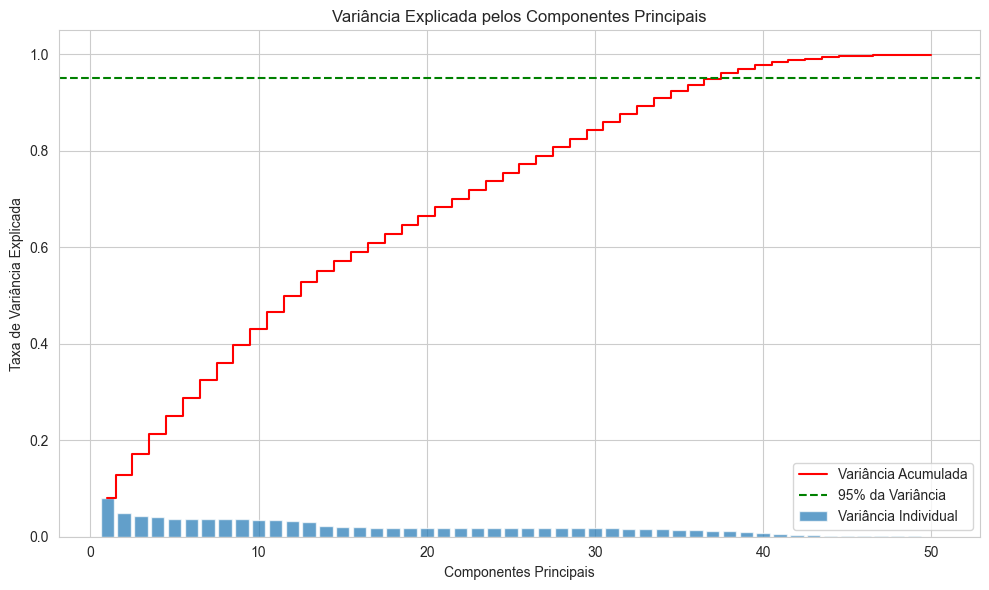

Número de Componentes para 95% da Variância: 38


In [21]:
try:
    print("Iniciando preparação de dados para PCA")

    ml_df_full = pd.concat([num_df, cat_dummies], axis=1)

    imputer_num = SimpleImputer(strategy='mean')
    ml_df_imputed_num = imputer_num.fit_transform(ml_df_full[num_cols])
    num_df_imputed = pd.DataFrame(ml_df_imputed_num, columns=num_cols, index=ml_df_full.index)
    ml_df_imputed_analysis = pd.concat([num_df_imputed, cat_dummies], axis=1)

    scaler = StandardScaler()
    ml_df_scaled = scaler.fit_transform(ml_df_imputed_analysis)

    print(f"Dataset pronto para ML. Shape: {ml_df_scaled.shape}")

    print("\n--- Executando PCA ---")
    pca = PCA()
    pca.fit(ml_df_scaled)

    explained_variance_ratio = pca.explained_variance_ratio_
    print(explained_variance_ratio)
    cumulative_variance = np.cumsum(explained_variance_ratio)

    plt.figure(figsize=(10, 6))
    num_components_to_plot = min(50, len(cumulative_variance))
    plt.bar(range(1, num_components_to_plot + 1), explained_variance_ratio[:num_components_to_plot], alpha=0.7, align='center', label='Variância Individual')
    plt.step(range(1, num_components_to_plot + 1), cumulative_variance[:num_components_to_plot], where='mid', label='Variância Acumulada', color='red')
    plt.axhline(y=0.95, color='g', linestyle='--', label='95% da Variância')
    plt.ylabel('Taxa de Variância Explicada'); plt.xlabel('Componentes Principais')
    plt.title('Variância Explicada pelos Componentes Principais'); plt.legend(loc='best')
    plt.grid(True); plt.tight_layout()
    plt.show()

    n_components_95_idx = np.where(cumulative_variance >= 0.95)[0]
    if n_components_95_idx.size > 0:
        n_components_95 = n_components_95_idx[0] + 1
    else:
        n_components_95 = len(cumulative_variance)

    print(f"Número de Componentes para 95% da Variância: {n_components_95}")




except NameError as e:
    print(f"ERRO: DataFrame 'laps_with_weather' não foi encontrado ({e}).")
    print("Por favor, execute a célula que carrega e processa os dados de UMA corrida primeiro (a que cria 'laps_with_weather').")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

In [22]:
def plot_pca_loadings_subset_3d(pca, feature_list, full_feature_list, title):

    loadings = pca.components_.T
    pc1 = loadings[:, 0]
    pc2 = loadings[:, 1]
    pc3 = loadings[:, 2]

    idx = [full_feature_list.get_loc(feat) for feat in feature_list]

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=pc1[idx],
        y=pc2[idx],
        z=pc3[idx],
        mode='markers+text',
        text=[full_feature_list[i] for i in idx],
        textposition="top center",
        marker=dict(
            size=6,
            line=dict(width=1, color='black')
        )
    ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3",
        ),
        width=800,
        height=700
    )

    fig.show()

feature_names = ml_df_imputed_analysis.columns

lap_tyres_features = [
    'LapTime_seconds', 'LapTime_prev', 'TyreLife', 'LapNumber', 'pirelliCompound_C5', 'pirelliCompound_C4',
    'pirelliCompound_C3', 'pirelliCompound_C2']

plot_pca_loadings_subset_3d(
    pca,
    lap_tyres_features,
    feature_names,
    title="Loadings PCA — Variáveis Tempo de Volta e Pneus"
)

weather_features = [
    'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median', 'TrackTemp_RBF_Median', 'TempDelta_RBF_Median', 'WindDirection_RBF_Median'
]

plot_pca_loadings_subset_3d(
    pca,
    weather_features,
    feature_names,
    title="Loadings PCA — Clima"
)

team_features = [col for col in feature_names if col.startswith('Team_')]
plot_pca_loadings_subset_3d(
    pca,
    team_features,
    feature_names,
    title="Loadings PCA — Equipes"
)

driver_features = [col for col in feature_names if col.startswith('Driver_')]
plot_pca_loadings_subset_3d(
    pca,
    driver_features,
    feature_names,
    title="Loadings PCA — Pilotos"
)

year_features = [col for col in feature_names if col.startswith('Year_')]
plot_pca_loadings_subset_3d(
    pca,
    year_features,
    feature_names,
    title="Loadings PCA — Anos"
)

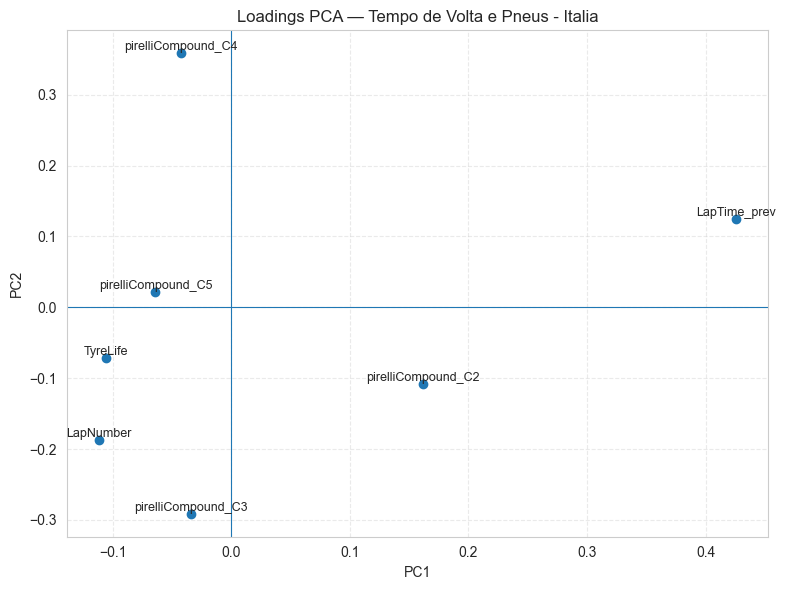

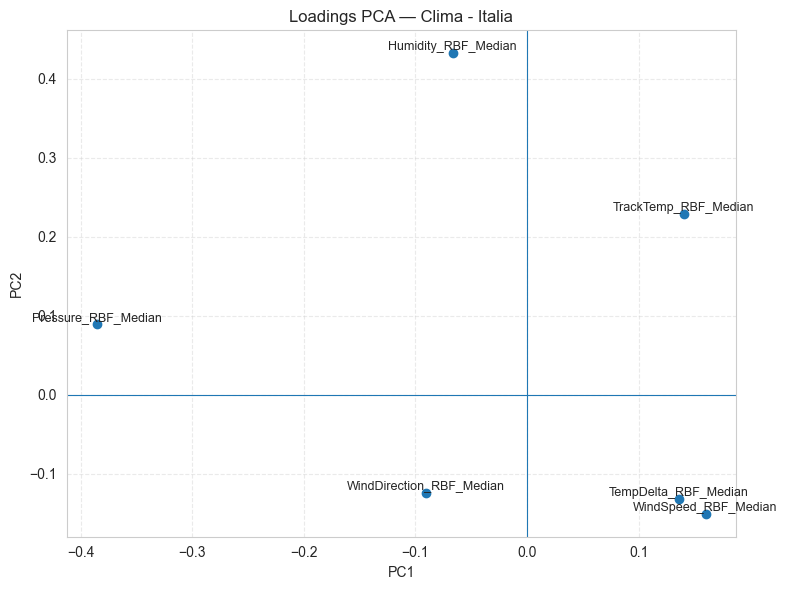

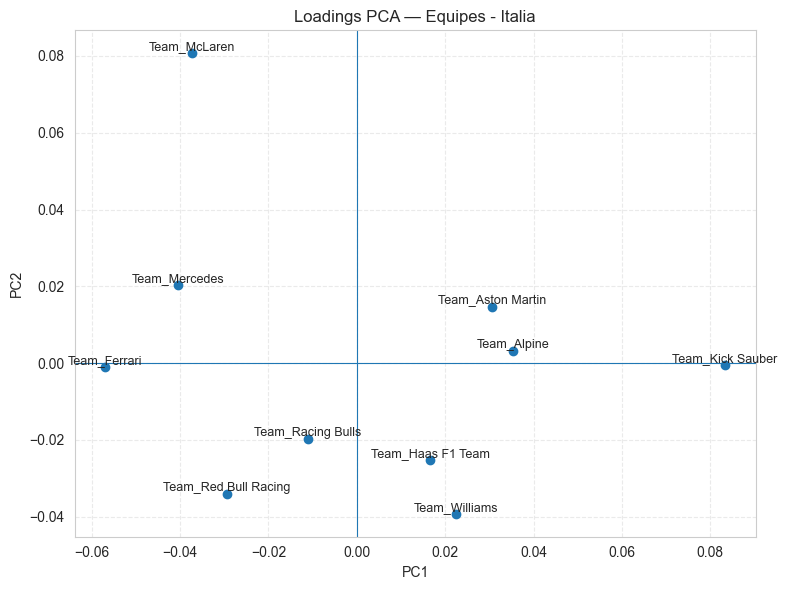

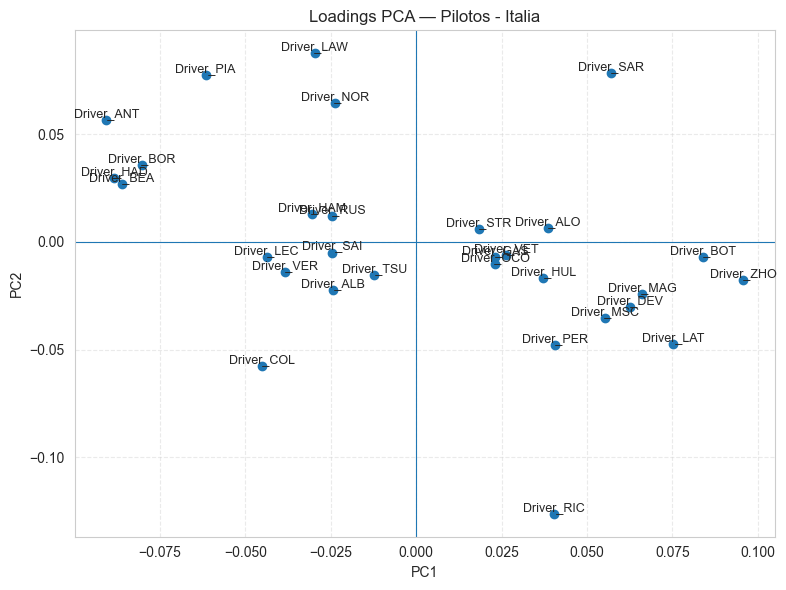

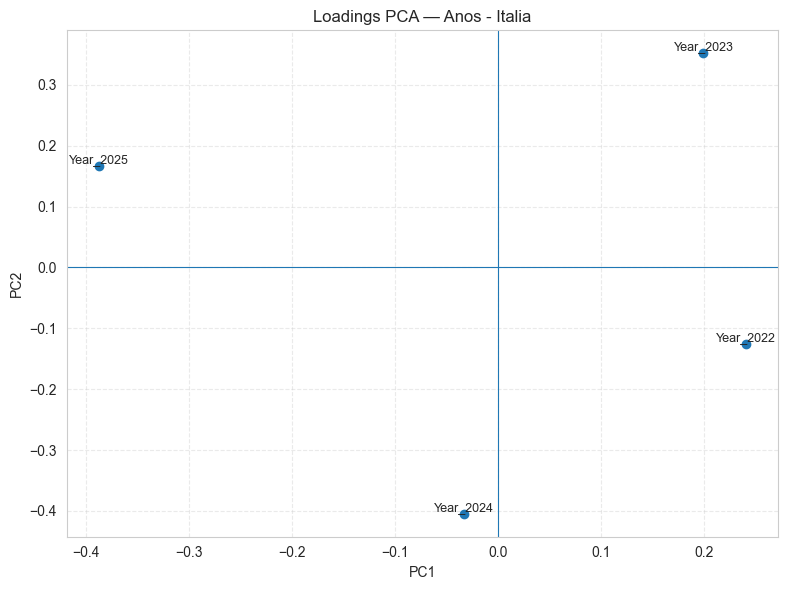

In [23]:
def plot_pca_loadings_subset_2d_static(pca, subset_features, full_feature_names, title):
    loadings = pca.components_.T
    pc1 = loadings[:, 0]
    pc2 = loadings[:, 1]

    if not isinstance(full_feature_names, pd.Index):
        full_feature_names = pd.Index(full_feature_names)

    subset_features = [f for f in subset_features if f in full_feature_names]
    if len(subset_features) == 0:
        print(f"[AVISO] Nenhuma feature encontrada: {title}")
        return

    idx = [full_feature_names.get_loc(f) for f in subset_features]

    plt.figure(figsize=(8, 6))
    plt.scatter(pc1[idx], pc2[idx])

    for i, feat in zip(idx, subset_features):
        plt.text(pc1[i], pc2[i], feat, fontsize=9, ha='center', va='bottom')

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

feature_names = ml_df_imputed_analysis.columns
plot_pca_loadings_subset_2d_static(
    pca,
    [
        'LapTime_prev', 'TyreLife', 'LapNumber',
        'pirelliCompound_C4', 'pirelliCompound_C2', 'pirelliCompound_C3', 'pirelliCompound_C5'
    ],
    feature_names,
    "Loadings PCA — Tempo de Volta e Pneus - Italia"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [
        'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median',
        'TrackTemp_RBF_Median', 'TempDelta_RBF_Median', 'WindDirection_RBF_Median'
    ],
    feature_names,
    "Loadings PCA — Clima - Italia"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Team_")],
    feature_names,
    "Loadings PCA — Equipes - Italia"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Driver_")],
    feature_names,
    "Loadings PCA — Pilotos - Italia"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Year_")],
    feature_names,
    "Loadings PCA — Anos - Italia"
)

## 16. Modelagem Preditiva: Estabelecimento do Baseline (Regressão Linear)

Antes de aplicar algoritmos complexos de "caixa preta" (como Gradient Boosting), é boa prática científica estabelecer um **Baseline** utilizando um modelo linear simples e interpretável.

O objetivo da **Regressão Linear Múltipla** aqui é duplo:
1.  **Definir um Benchmark:** Estabelecer o erro mínimo aceitável (RMSE) e a explicação de variância ($R^2$) que qualquer modelo avançado deve superar.
2.  **Validar Relações Físicas:** Analisar os coeficientes ($\beta$) para confirmar se as variáveis se comportam conforme a física (ex: `TyreLife` deve ter coeficiente positivo, aumentando o tempo).

### Pré-processamento Rigoroso para Modelos Lineares:
Diferente de árvores de decisão, a regressão linear é sensível à escala e multicolineariedade. Por isso, aplicamos:

* **Prevenção da Armadilha das Variáveis Dummy:** Ao usar *One-Hot Encoding* em variáveis categóricas (Equipes, Pilotos), utilizamos `drop_first=True`. Isso remove uma coluna de cada categoria (ex: remove a equipe 'Ferrari' e a usa como referência), evitando a **Multicolineariedade Perfeita** (onde uma variável pode ser prevista perfeitamente pelas outras), que quebraria a inversão da matriz algébrica.
* **Padronização (`StandardScaler`):** Transformamos todas as variáveis numéricas para a mesma escala (Média=0, Desvio Padrão=1). Sem isso, o coeficiente de `Pressure` (~1000 hPa) seria artificialmente minúsculo comparado ao de `TyreLife` (~10 voltas), tornando a interpretação dos pesos impossível.

In [24]:
target_col = 'LapTime_seconds'

num_cols = [
    'TyreLife', 'LapNumber',
    'Humidity_RBF_Median','Pressure_RBF_Median', 'TrackTemp_RBF_Median', 'WindSpeed_RBF_Median', 'TempDelta_RBF_Median', 'WindDirection_RBF_Median', 'LapTime_prev']

cat_cols = ['Driver', 'Team', 'pirelliCompound', 'Year']

print("Preparando dados para Regressão Linear (Baseline)...")

num_cols = [c for c in num_cols if c in laps_cleaned.columns]
cat_cols = [c for c in cat_cols if c in laps_cleaned.columns]


X_base = laps_cleaned[num_cols + cat_cols].copy()
y = laps_cleaned[target_col].copy()

valid_indices = y.dropna().index
X_base = X_base.loc[valid_indices]
y = y.loc[valid_indices]

X_encoded = pd.get_dummies(X_base, columns=cat_cols, drop_first=True)

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_encoded), columns=X_encoded.columns)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)

print(f"Shape final de X: {X_scaled.shape}")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Treinando Regressão Linear...")
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_train = model_lr.predict(X_train)
y_pred_test = model_lr.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n--- RESULTADOS DO BASELINE (Regressão Linear) ---")
print(f"RMSE (Erro Médio Quadrático): {rmse_test:.4f} segundos")
print(f"MAE (Erro Médio Absoluto):    {mae_test:.4f} segundos")
print(f"R² (Coef. de Determinação):   {r2_test:.4f}")

coefs = pd.DataFrame({'Feature': X_scaled.columns, 'Coef': model_lr.coef_})
coefs['Abs_Coef'] = coefs['Coef'].abs()
print("\nVariáveis Mais Impactantes:")
display(coefs.sort_values(by='Abs_Coef', ascending=False))

Preparando dados para Regressão Linear (Baseline)...
Shape final de X: (2994, 53)
Treinando Regressão Linear...

--- RESULTADOS DO BASELINE (Regressão Linear) ---
RMSE (Erro Médio Quadrático): 0.2660 segundos
MAE (Erro Médio Absoluto):    0.2063 segundos
R² (Coef. de Determinação):   0.9759

Variáveis Mais Impactantes:


,Feature,Coef,Abs_Coef
8,LapTime_prev,1.424295,1.424295
52,Year_2025,-0.160632,0.160632
51,Year_2024,-0.153824,0.153824
1,LapNumber,-0.142239,0.142239
3,Pressure_RBF_Median,-0.112673,0.112673
0,TyreLife,0.079081,0.079081
43,Team_Mercedes,-0.071069,0.071069
39,Team_Ferrari,-0.067543,0.067543
28,Driver_PIA,-0.061648,0.061648
25,Driver_NOR,-0.061383,0.061383


## 17. Diagnóstico de Resíduos e Validação de Premissas

Após treinar o modelo, não basta olhar apenas o erro médio (RMSE). Precisamos investigar os **Resíduos** (Erro = Real - Predito) para garantir que o modelo não está enviesado.

Os 4 gráficos de diagnóstico gerados abaixo nos contam a seguinte história:

1.  **Resíduos vs Preditos (Homoscedasticidade):** Queremos ver uma "nuvem" aleatória sem padrões. Se houver uma forma de funil (erros maiores em voltas mais lentas), o modelo viola a premissa de variância constante.
2.  **QQ-Plot (Normalidade):** Se os pontos seguirem a linha vermelha, os erros são normais (Gaussiana). Desvios nas pontas indicam "caudas pesadas" (o modelo erra feio em eventos raros, como Safety Cars).
3.  **Resíduos vs Índice (Independência):** Verifica se o erro de uma volta depende da volta anterior. Se houver um padrão de onda, faltou modelar alguma variável temporal.
4.  **Real vs Predito:** O gráfico de aderência ideal ($y=x$). Quanto mais próximos os pontos estiverem da linha tracejada vermelha, melhor a previsão.

Gerando diagnósticos para Regressão Linear...


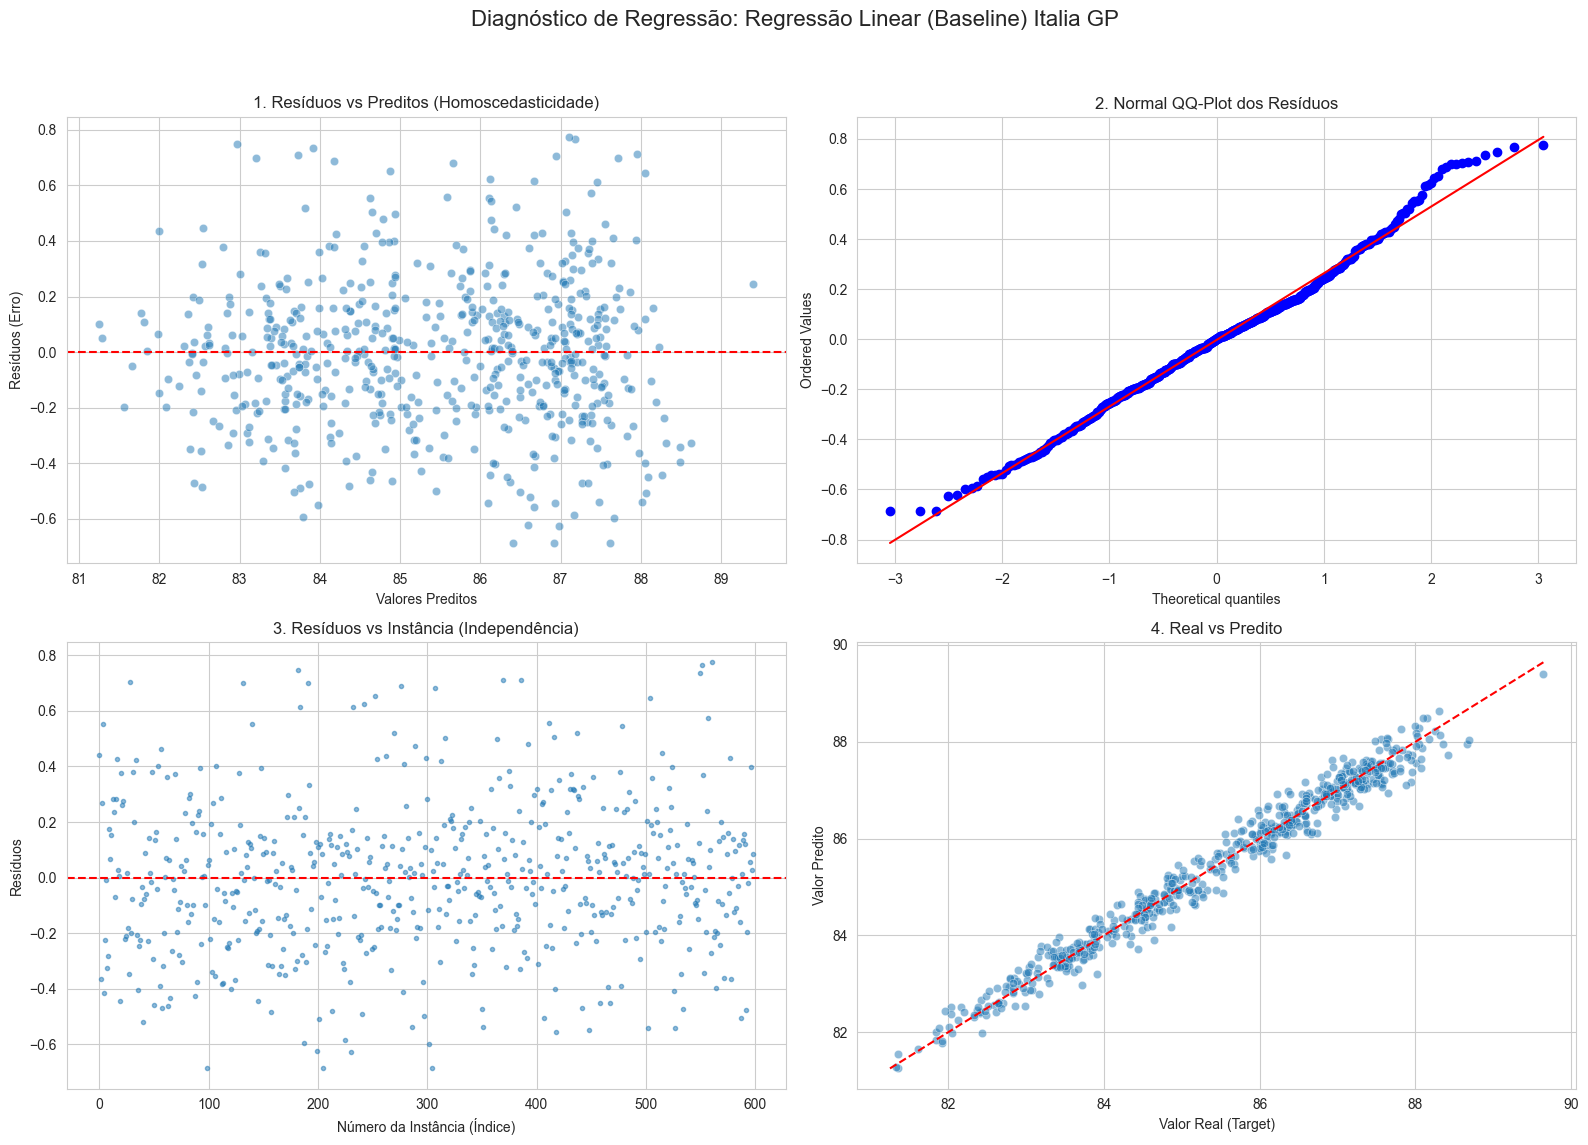

In [25]:
def plot_regression_diagnostics(y_true, y_pred, model_name):
    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Diagnóstico de Regressão: {model_name}', fontsize=16)

    sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 0], alpha=0.5)
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_xlabel('Valores Preditos')
    axes[0, 0].set_ylabel('Resíduos (Erro)')
    axes[0, 0].set_title('1. Resíduos vs Preditos (Homoscedasticidade)')

    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('2. Normal QQ-Plot dos Resíduos')

    axes[1, 0].plot(residuals.values, marker='o', linestyle='none', alpha=0.5, markersize=3)
    axes[1, 0].axhline(0, color='red', linestyle='--')
    axes[1, 0].set_xlabel('Número da Instância (Índice)')
    axes[1, 0].set_ylabel('Resíduos')
    axes[1, 0].set_title('3. Resíduos vs Instância (Independência)')

    sns.scatterplot(x=y_true, y=y_pred, ax=axes[1, 1], alpha=0.5)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--')

    axes[1, 1].set_xlabel('Valor Real (Target)')
    axes[1, 1].set_ylabel('Valor Predito')
    axes[1, 1].set_title('4. Real vs Predito')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def calculate_confidence_intervals(y_true, y_pred, metric_func, metric_name, n_bootstraps=1000):
    bootstrapped_scores = []
    rng = np.random.RandomState(42)

    y_true = y_true.reset_index(drop=True)
    y_pred = pd.Series(y_pred)

    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(y_true[indices])) < 2:
            continue

        score = metric_func(y_true[indices], y_pred[indices])
        if metric_name == 'RMSE':
             score = np.sqrt(score)

        bootstrapped_scores.append(score)

    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()

    confidence_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    confidence_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    mean_score = np.mean(sorted_scores)

    return mean_score, confidence_lower, confidence_upper

print("Gerando diagnósticos para Regressão Linear...")
plot_regression_diagnostics(y_test, y_pred_test, "Regressão Linear (Baseline) Italia GP")

In [26]:
print("Ajustando índices para o Statsmodels...")

X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

X_train_sm = sm.add_constant(X_train_reset)

print("Treinando modelo OLS...")
model_sm = sm.OLS(y_train_reset, X_train_sm).fit()

print(model_sm.summary())

Ajustando índices para o Statsmodels...
Treinando modelo OLS...
                            OLS Regression Results                            
Dep. Variable:        LapTime_seconds   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     1954.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:48:48   Log-Likelihood:                -229.26
No. Observations:                2395   AIC:                             564.5
Df Residuals:                    2342   BIC:                             870.9
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

## 18. Otimização Estatística: Backward Elimination com Intervalos de Confiança

Utilizamos um modelo de **Regressão Linear** com todas as variáveis como ponto de partida (Baseline). No entanto, um modelo com muitas variáveis irrelevantes sofre de *overfitting* (decora ruídos) e é difícil de interpretar.

Para encontrar o subconjunto ideal de variáveis, implementamos o algoritmo de **Backward Elimination** com um rigoroso teste de hipótese a cada passo.

### Lógica do Algoritmo:
1.  **Iteração:** Em cada passo, treinamos o modelo e calculamos o P-Valor de cada variável.
2.  **Eliminação:** Removemos a variável com o maior P-Valor (se $P > 0.05$).
3.  **Verificação de Qualidade (Inovação deste TCC):**
    * A cada remoção, recalculamos o **RMSE com Intervalo de Confiança de 95%** (usando a distribuição t-Student).
    * **Critério de Segurança:** Se o intervalo de erro do novo modelo simplificado se sobrepõe ao intervalo do modelo completo, concluímos que **não houve perda estatisticamente significativa** de performance.

Isso nos permite reduzir a complexidade drasticamente (de ~50 para ~15 variáveis) mantendo a mesma precisão preditiva, comprovado matematicamente pela sobreposição dos intervalos de confiança.

## Backward Elimination

Fizemos modelos com todas as variavéis, agora vou removendo os grupos e algumas delas para testes.

In [27]:
def calculate_metrics_and_ci(residuals, confidence=0.95):
    squared_errors = residuals ** 2
    mse = squared_errors.mean()
    rmse_val = np.sqrt(mse)

    mse_ci = stats.t.interval(confidence, len(squared_errors)-1,
                              loc=mse, scale=stats.sem(squared_errors))
    rmse_ci = (np.sqrt(max(0, mse_ci[0])), np.sqrt(mse_ci[1]))

    abs_errors = np.abs(residuals)
    mae_val = abs_errors.mean()
    mae_ci = stats.t.interval(confidence, len(abs_errors)-1,
                              loc=mae_val, scale=stats.sem(abs_errors))

    return rmse_val, rmse_ci, mae_val, mae_ci

print("Calculando Baseline (Modelo Completo)...")
n_obs = len(y_train)

full_model = sm.OLS(y_train.values, X_train_sm).fit()

rmse_full, ci_rmse_full, mae_full, ci_mae_full = calculate_metrics_and_ci(full_model.resid)

print(f"BASELINE (Full):")
print(f"  RMSE: {rmse_full:.4f} | IC 95%: [{ci_rmse_full[0]:.4f}, {ci_rmse_full[1]:.4f}]")
print(f"  MAE:  {mae_full:.4f} | IC 95%: [{ci_mae_full[0]:.4f}, {ci_mae_full[1]:.4f}]")

features = list(X_train_sm.columns)
history = []

print("\nIniciando Backward Elimination...")
header = f"{'Passo':<5} | {'Var. Removida':<26} | {'P-val':<8} | {'RMSE (IC 95%)':<28} | {'MAE (IC 95%)':<28} | {'Sig?':<5}"
print("-" * len(header))
print(header)
print("-" * len(header))

step = 0
while len(features) > 0:
    X_curr = X_train_sm[features]
    model = sm.OLS(y_train.values, X_curr).fit()

    rmse_curr, ci_rmse_curr, mae_curr, ci_mae_curr = calculate_metrics_and_ci(model.resid)

    rss = model.ssr
    p = len(features)
    rmse_overlap = not (ci_rmse_curr[0] > ci_rmse_full[1])
    significativo = "NAO" if rmse_overlap else "SIM!"

    p_values = model.pvalues
    max_p_value = p_values.max()
    worst_feature = p_values.idxmax()

    if max_p_value > 0.05:
        features.remove(worst_feature)

        rmse_str = f"{rmse_curr:.3f} [{ci_rmse_curr[0]:.3f}, {ci_rmse_curr[1]:.3f}]"
        mae_str = f"{mae_curr:.3f} [{ci_mae_curr[0]:.3f}, {ci_mae_curr[1]:.3f}]"

        history.append({
            'Step': step,
            'Removed': worst_feature,
            'RMSE': rmse_curr,
            'RMSE_Lower': ci_rmse_curr[0],
            'RMSE_Upper': ci_rmse_curr[1],
            'Significant_Change': significativo
        })

        print(f"{step:<5} | {worst_feature:<26} | {max_p_value:.4f}   | {rmse_str:<28} | {mae_str:<28} | {significativo:<5}")
        step += 1
    else:
        print("-" * len(header))
        print(f"Parada! P-values < 0.05.")
        print(f"Modelo Final: {len(features)} variáveis.")
        print(f"RMSE Final: {rmse_curr:.4f} [{ci_rmse_curr[0]:.4f}, {ci_rmse_curr[1]:.4f}]")
        break


print("\nVariáveis Finais:")
print(features)
final_model = sm.OLS(y_train.values, X_train_sm[features]).fit()
print(final_model.summary())

Calculando Baseline (Modelo Completo)...
BASELINE (Full):
  RMSE: 0.2663 | IC 95%: [0.2579, 0.2744]
  MAE:  0.2066 | IC 95%: [0.1998, 0.2133]

Iniciando Backward Elimination...
-------------------------------------------------------------------------------------------------------------------
Passo | Var. Removida              | P-val    | RMSE (IC 95%)                | MAE (IC 95%)                 | Sig? 
-------------------------------------------------------------------------------------------------------------------
0     | Team_Racing Bulls          | 0.9447   | 0.266 [0.258, 0.274]         | 0.207 [0.200, 0.213]         | NAO  
1     | Team_Red Bull Racing       | 0.8787   | 0.266 [0.258, 0.274]         | 0.207 [0.200, 0.213]         | NAO  
2     | Driver_GAS                 | 0.8662   | 0.266 [0.258, 0.274]         | 0.207 [0.200, 0.213]         | NAO  
3     | Driver_LAW                 | 0.9061   | 0.266 [0.258, 0.274]         | 0.207 [0.200, 0.213]         | NAO  
4     | Dri

## 20. Refinamento do Baseline (5 Splits)

Para garantir uma comparação estatisticamente justa com o modelo avançado (XGBoost), submetemos o **Baseline Linear** ao mesmo protocolo de validação rigorosa.

Em vez de confiar em uma única divisão de Treino/Teste (que pode ser "sortuda" ou "azarada"), realizamos:
1.  **5 Divisões Aleatórias (Splits):** Separamos os dados em 80/20 cinco vezes, mudando a semente aleatória (`random_state`) em cada iteração.
2.  **Cálculo de ICs:** Geramos a média e o Intervalo de Confiança (95%) para RMSE, MAE e $R^2$.

**Objetivo:** Se o limite inferior do intervalo de confiança do XGBoost for maior que o limite superior deste Baseline, teremos a prova definitiva e irrefutável de que a não-linearidade é necessária para modelar este problema.

In [28]:
print("--- PREPARAÇÃO E VALIDAÇÃO ROBUSTA DO BASELINE (MONTE CARLO) ---")

target_col = 'LapTime_seconds'
df_base = laps_cleaned.copy()

num_cols_base = [
    'TyreLife', 'LapNumber',
    'Humidity_RBF_Median','Pressure_RBF_Median', 'TrackTemp_RBF_Median',
    'WindSpeed_RBF_Median',
    'TempDelta_RBF_Median', 'LapTime_prev'
]

cat_cols_base = ['Driver', 'Team', 'pirelliCompound', 'Year']

num_cols_base = [c for c in num_cols_base if c in df_base.columns]
cat_cols_base = [c for c in cat_cols_base if c in df_base.columns]

X_raw = df_base[num_cols_base + cat_cols_base].copy()
y_raw = df_base[target_col].copy()
valid_indices = y_raw.dropna().index
X_raw = X_raw.loc[valid_indices]
y_raw = y_raw.loc[valid_indices]

X_encoded = pd.get_dummies(X_raw, columns=cat_cols_base, drop_first=True)

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)

scaler = StandardScaler()
X_final = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns, index=X_imputed.index)
y_final = y_raw

print(f"Dados preparados. Shape X: {X_final.shape}, Shape y: {y_final.shape}")

np.random.seed(42)

results_baseline = {
    'seed_usada': [],
    'rmse': [],
    'mae': [],
    'r2': []
}

N_SPLITS = 5

for i in range(N_SPLITS):
    seed_da_rodada = np.random.randint(0, 100000)

    print(f"\nSplit {i+1}/{N_SPLITS} | Seed Sorteada: {seed_da_rodada}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_final, y_final,
        test_size=0.20,
        random_state=seed_da_rodada,
        shuffle=True
    )

    model = LinearRegression()
    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)

    rmse_val = np.sqrt(mean_squared_error(y_te, preds))
    mae_val = mean_absolute_error(y_te, preds)
    r2_val = r2_score(y_te, preds)

    results_baseline['seed_usada'].append(seed_da_rodada)
    results_baseline['rmse'].append(rmse_val)
    results_baseline['mae'].append(mae_val)
    results_baseline['r2'].append(r2_val)

    print(f"   Resultado: RMSE={rmse_val:.4f} | MAE={mae_val:.4f} | R2={r2_val:.4f}")


def calc_stats(values):
    mean_v = np.mean(values)
    ci = stats.t.interval(0.95, len(values)-1, loc=mean_v, scale=stats.sem(values))
    return mean_v, ci[0], ci[1]

rmse_m, rmse_l, rmse_u = calc_stats(results_baseline['rmse'])
mae_m, mae_l, mae_u = calc_stats(results_baseline['mae'])
r2_m, r2_l, r2_u = calc_stats(results_baseline['r2'])

mean_rmse_lr, lower_rmse_lr, upper_rmse_lr = rmse_m, rmse_l, rmse_u
mean_mae_lr, lower_mae_lr, upper_mae_lr = mae_m, mae_l, mae_u
mean_r2_lr, lower_r2_lr, upper_r2_lr = r2_m, r2_l, r2_u

print("\n--- RESULTADOS FINAIS DO BASELINE ROBUSTO ---")
print(f"RMSE: {rmse_m:.4f}  IC95%: [{rmse_l:.4f}, {rmse_u:.4f}]")
print(f"MAE:  {mae_m:.4f}  IC95%: [{mae_l:.4f}, {mae_u:.4f}]")
print(f"R²:   {r2_m:.4f}  IC95%: [{r2_l:.4f}, {r2_u:.4f}]")

df_res_base = pd.DataFrame(results_baseline)

--- PREPARAÇÃO E VALIDAÇÃO ROBUSTA DO BASELINE (MONTE CARLO) ---


Dados preparados. Shape X: (2994, 52), Shape y: (2994,)

Split 1/5 | Seed Sorteada: 15795
   Resultado: RMSE=0.2754 | MAE=0.2142 | R2=0.9754

Split 2/5 | Seed Sorteada: 860
   Resultado: RMSE=0.2734 | MAE=0.2159 | R2=0.9767

Split 3/5 | Seed Sorteada: 76820
   Resultado: RMSE=0.2807 | MAE=0.2161 | R2=0.9730

Split 4/5 | Seed Sorteada: 54886
   Resultado: RMSE=0.2753 | MAE=0.2127 | R2=0.9758

Split 5/5 | Seed Sorteada: 6265
   Resultado: RMSE=0.2605 | MAE=0.2039 | R2=0.9790

--- RESULTADOS FINAIS DO BASELINE ROBUSTO ---
RMSE: 0.2731  IC95%: [0.2637, 0.2824]
MAE:  0.2126  IC95%: [0.2063, 0.2188]
R²:   0.9760  IC95%: [0.9733, 0.9787]


## 19. Refinamento Não-Linear: Otimização de Hiperparâmetros e Validação Robusta (XGBoost)

Superando as limitações da linearidade, implementamos o **XGBoost (Extreme Gradient Boosting)**, um algoritmo de estado da arte baseado em árvores de decisão. Para garantir a máxima performance e evitar *overfitting*, adotamos um protocolo rigoroso de treinamento em três etapas:

### 1. Busca em Grade (`GridSearchCV`)
Em vez de arbitrar os parâmetros do modelo, realizamos uma busca exaustiva para encontrar a combinação ótima que minimiza o RMSE.
* **Espaço de Busca:** Testamos variações de complexidade da árvore (`max_depth`), número de estimadores (`n_estimators`), taxa de aprendizado (`learning_rate`) e regularização estocástica (`subsample`, `colsample_bytree`).
* **Validação Interna:** Cada combinação foi validada via *5-Fold Cross-Validation*.



### 2. Validação de Estabilidade (Monte Carlo Cross-Validation)
Para provar que o modelo não "teve sorte" em uma divisão específica de treino/teste, realizamos um **Loop de Validação Robusta**:
* Dividimos o dataset completo aleatoriamente 5 vezes (5 *Splits* distintos).
* Em cada iteração, retreinamos o modelo do zero usando os melhores hiperparâmetros encontrados.

### 3. Inferência Estatística (Bootstrapping)
Para cada uma das 5 iterações, calculamos não apenas a média do erro, mas o **Intervalo de Confiança de 95%** via *Bootstrapping*.
* Isso gera um resultado final extremamente sólido: *"Temos 95% de confiança de que o R² do modelo oscila entre X e Y, independente de como os dados são divididos."*

Este método garante a reprodutibilidade e a robustez científica dos resultados apresentados.

In [29]:
print("--- PREPARAÇÃO PARA XGBOOST (SEM ONE_HOT_THRESH, DRIVER ONE-HOT) ---")

X_proc = X_raw.copy()

X_proc[cat_cols] = X_proc[cat_cols].fillna("Missing")

X_proc = pd.get_dummies(X_proc, columns=cat_cols, drop_first=True)

X_proc[num_cols_base] = X_proc[num_cols_base].fillna(X_proc[num_cols_base].median())

X = X_proc
y = y_raw.copy()

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.20, random_state=42
)


rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_holdout)
rf_rmse = np.sqrt(mean_squared_error(y_holdout, rf_preds))
rf_r2 = r2_score(y_holdout, rf_preds)
rf_mae = mean_absolute_error(y_holdout, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)
print("Random Forest MAE:", rf_mae)


dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_holdout, label=y_holdout)

base_params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42,
}

baseline = xgb.train(
    params=base_params,
    dtrain=dtrain,
    num_boost_round=200,
    evals=[(dvalid, "validation")],
    early_stopping_rounds=20,
    verbose_eval=False
)

preds = baseline.predict(dvalid, iteration_range=(0, baseline.best_iteration + 1))
baseline_rmse_xgb = np.sqrt(mean_squared_error(y_holdout, preds))
baseline_mae_xgb = mean_absolute_error(y_holdout, preds)
baseline_r2_xgb = r2_score(y_holdout, preds)

print("Baseline XGB RMSE:", baseline_rmse_xgb)
print("Baseline XGB MAE:", baseline_mae_xgb)
print("Baseline XGB R2:", baseline_r2_xgb)

params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42,
}

simple = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=[(dvalid, "validation")],
    early_stopping_rounds=50,
    verbose_eval=False
)

preds = simple.predict(dvalid, iteration_range=(0, simple.best_iteration + 1))
simple_rmse = np.sqrt(mean_squared_error(y_holdout, preds))
simple_mae = mean_absolute_error(y_holdout, preds)
simple_r2 = r2_score(y_holdout, preds)

print("Simple Model RMSE:", simple_rmse)
print("Simple Model MAE:", simple_mae)
print("Simple Model R2:", simple_r2)

print("\n--- TUNAGEM OPTUNA ---")

def objective(trial):
    param = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "eval_metric": "rmse",
        "seed": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    rmse_scores = []

    for train_idx, val_idx in kf.split(X_train):
        dtr = xgb.DMatrix(X_train.iloc[train_idx], label=y_train.iloc[train_idx])
        dva = xgb.DMatrix(X_train.iloc[val_idx], label=y_train.iloc[val_idx])

        bst = xgb.train(
            params=param,
            dtrain=dtr,
            num_boost_round=2000,
            evals=[(dva, "validation")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        preds = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
        rmse_scores.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds)))

    return float(np.mean(rmse_scores))

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=40, show_progress_bar=False)

best_params = study.best_params
print("\nBest params (Optuna):")
print(best_params)
print("Best CV RMSE:", study.best_value)

best_params_train = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42,
    **best_params
}

dtrain_full = xgb.DMatrix(X_train, label=y_train)
dhold = xgb.DMatrix(X_holdout, label=y_holdout)

final = xgb.train(
    params=best_params_train,
    dtrain=dtrain_full,
    num_boost_round=5000,
    evals=[(dhold, "validation")],
    early_stopping_rounds=100,
    verbose_eval=50
)

final_preds = final.predict(dhold, iteration_range=(0, final.best_iteration + 1))
final_rmse = np.sqrt(mean_squared_error(y_holdout, final_preds))
final_mae = mean_absolute_error(y_holdout, final_preds)
final_r2 = r2_score(y_holdout, final_preds)
print("Final RMSE:", final_rmse)
print("Final MAE:", final_mae)
print("Final R2:", final_r2)


print("\n--- CALIBRANDO N_ESTIMATORS (xgb.cv) COM BEST PARAMS ---")

cv_results = xgb.cv(
    params=best_params_train,
    dtrain=dtrain_full,
    num_boost_round=5000,
    nfold=3,
    metrics="rmse",
    early_stopping_rounds=100,
    seed=42,
    verbose_eval=False
)

best_n = cv_results.shape[0]
print("Melhor n_estimators (cv):", best_n)

final_params = {
    **best_params,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "n_estimators": best_n
}

print("\nParâmetros Finais Otimizados (para Monte Carlo):")
print(final_params)

print("\n--- INICIANDO COMPARAÇÃO PAREADA (XGBOOST OPTUNA + EARLY STOPPING POR SPLIT) ---")

results_xgb = {"seed_usada": [], "rmse": [], "mae": [], "r2": []}
seeds_do_baseline = results_baseline["seed_usada"]

optuna_params_train = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42,
    **best_params
}

best_r2 = -np.inf
best_rmse = np.inf
best_mae = np.inf

best_model = None
best_seed = None
best_X_tr = None
best_y_te = None
best_dte = None
best_preds = None

for i, seed in enumerate(seeds_do_baseline):

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=0.20,
        random_state=seed,
        shuffle=True
    )

    feature_names = list(X_tr.columns)

    dtr = xgb.DMatrix(X_tr, label=y_tr, feature_names=feature_names)
    dte = xgb.DMatrix(X_te, label=y_te, feature_names=feature_names)

    bst = xgb.train(
        params=optuna_params_train,
        dtrain=dtr,
        num_boost_round=5000,
        evals=[(dte, "validation")],
        early_stopping_rounds=100,
        verbose_eval=False
    )

    preds = bst.predict(dte, iteration_range=(0, bst.best_iteration + 1))

    rmse_val = np.sqrt(mean_squared_error(y_te, preds))
    mae_val  = mean_absolute_error(y_te, preds)
    r2_val   = r2_score(y_te, preds)

    results_xgb["seed_usada"].append(seed)
    results_xgb["rmse"].append(rmse_val)
    results_xgb["mae"].append(mae_val)
    results_xgb["r2"].append(r2_val)


    is_better = (
        (rmse_val < best_rmse) or
        (np.isclose(rmse_val, best_rmse) and r2_val > best_r2) or
        (np.isclose(rmse_val, best_rmse) and np.isclose(r2_val, best_r2) and mae_val < best_mae)
    )

    if is_better:
        best_r2 = r2_val
        best_rmse = rmse_val
        best_mae = mae_val

        best_model = bst
        best_seed = seed
        best_X_tr = X_tr.copy()
        best_y_te = y_te.copy()
        best_dte = dte
        best_preds = preds

    print(f"Split {i+1} | Seed {seed} | best_iter={bst.best_iteration} | RMSE={rmse_val:.4f} | R2={r2_val:.4f}")

rmse_m_xgb, rmse_l_xgb, rmse_u_xgb = calc_stats(results_xgb["rmse"])
mae_m_xgb, mae_l_xgb, mae_u_xgb = calc_stats(results_xgb["mae"])
r2_m_xgb, r2_l_xgb, r2_u_xgb = calc_stats(results_xgb["r2"])

print("\n--- RESULTADO FINAL XGBOOST (OPTUNA + ES POR SPLIT) ---")
print(f"RMSE Médio: {rmse_m_xgb:.4f} IC95%: [{rmse_l_xgb:.4f}, {rmse_u_xgb:.4f}]")
print(f"MAE  Médio: {mae_m_xgb:.4f} IC95%: [{mae_l_xgb:.4f}, {mae_u_xgb:.4f}]")
print(f"R2   Médio: {r2_m_xgb:.4f} IC95%: [{r2_l_xgb:.4f}, {r2_u_xgb:.4f}]")

--- PREPARAÇÃO PARA XGBOOST (SEM ONE_HOT_THRESH, DRIVER ONE-HOT) ---


Random Forest RMSE: 0.2739737719862857
Random Forest R2: 0.9744535615769689
Random Forest MAE: 0.21000999999999742
Baseline XGB RMSE: 0.278188881239975
Baseline XGB MAE: 0.21229492686785909
Baseline XGB R2: 0.9736614465580778


[I 2026-04-02 12:48:53,899] A new study created in memory with name: no-name-ed643edd-aa6f-44cf-8d47-86228f5963c0


Simple Model RMSE: 0.2603155928505621
Simple Model MAE: 0.19885779236553114
Simple Model R2: 0.9769371619544339

--- TUNAGEM OPTUNA ---


[I 2026-04-02 12:48:59,558] Trial 0 finished with value: 0.27601861092416263 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 10, 'min_child_weight': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 0.27601861092416263.
[I 2026-04-02 12:49:01,736] Trial 1 finished with value: 0.2822930167352499 and parameters: {'learning_rate': 0.06054365855469246, 'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 1.0616955533913808, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 0 with value: 0.27601861092416263.
[I 2026-04-02 12:49:08,757] Trial 2 finished with value: 0.2748466484055521 and parameters: {'learning_rate': 0.024878734419814436, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.7164916560792167, 'col


Best params (Optuna):
{'learning_rate': 0.010098811426854244, 'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.7869256126025419, 'colsample_bytree': 0.6464917586908827, 'gamma': 0.06948779089508372, 'reg_alpha': 2.8072213933928077e-06, 'reg_lambda': 0.05711175900089484}
Best CV RMSE: 0.26787813559275236
[0]	validation-rmse:1.69897
[50]	validation-rmse:1.07395
[100]	validation-rmse:0.70025
[150]	validation-rmse:0.48278
[200]	validation-rmse:0.36915
[250]	validation-rmse:0.30783
[300]	validation-rmse:0.27792
[350]	validation-rmse:0.26406
[400]	validation-rmse:0.25751
[450]	validation-rmse:0.25415
[500]	validation-rmse:0.25235
[550]	validation-rmse:0.25144
[600]	validation-rmse:0.25093
[650]	validation-rmse:0.25091
[700]	validation-rmse:0.25082
[750]	validation-rmse:0.25072
[800]	validation-rmse:0.25066
[850]	validation-rmse:0.25074
[891]	validation-rmse:0.25090
Final RMSE: 0.25059589879875865
Final MAE: 0.19076140267144456
Final R2: 0.9786272551338737

--- CALIBRANDO N_ESTIMATORS (


Melhor modelo do XGBoost treinado durante os splits:
Seed: 6265
R2: 0.9813038120212204
RMSE: 0.24589772610413385
MAE: 0.19086807928578853


,gain
Year_2025,254.959778
Year_2024,68.585274
LapTime_prev,44.646313
Year_2023,33.899834
Pressure_RBF_Median,31.986647
LapNumber,4.370886
Team_Red Bull Racing,4.241176
Team_Kick Sauber,3.954510
TrackTemp_RBF_Median,3.940882
Team_Ferrari,3.388195


C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\1367469500.py:29: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



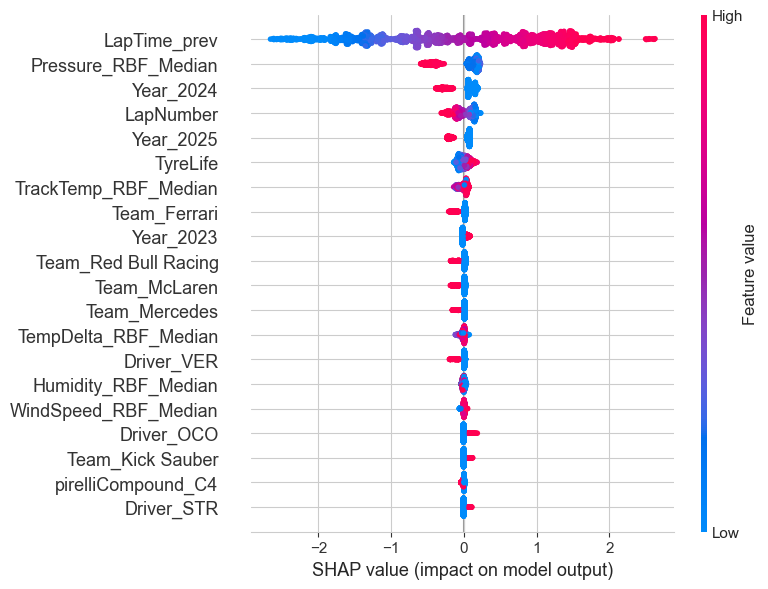

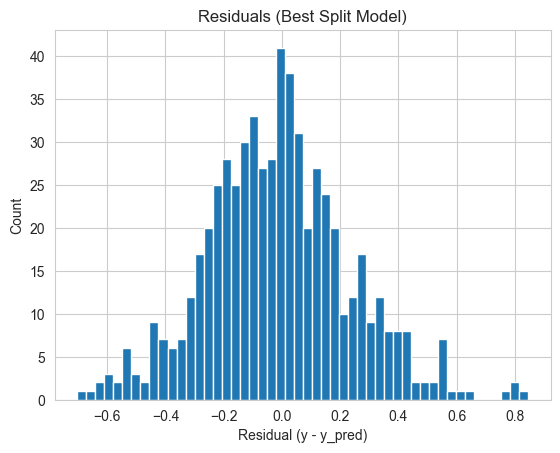

In [30]:
print("\nMelhor modelo do XGBoost treinado durante os splits:")
print("Seed:", best_seed)
print("R2:", best_r2)
print("RMSE:", best_rmse)
print("MAE:", best_mae)

importance = best_model.get_score(importance_type="gain")


if len(importance) > 0 and next(iter(importance.keys())).startswith("f"):
    colnames = list(best_X_tr.columns)
    importance_named = {colnames[int(k[1:])]: v for k, v in importance.items()}
else:
    importance_named = importance

importance_df = (
    pd.DataFrame.from_dict(importance_named, orient="index", columns=["gain"])
      .sort_values("gain", ascending=False)
)

display(importance_df.head(10))

shap.initjs()


explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(best_X_tr)

shap.summary_plot(shap_values, best_X_tr,plot_size=(8,6))


residuals_best = best_y_te.values - best_preds

plt.figure()
plt.hist(residuals_best, bins=50)
plt.title("Residuals (Best Split Model)")
plt.xlabel("Residual (y - y_pred)")
plt.ylabel("Count")
plt.savefig("residuals_best_model.png", bbox_inches="tight", dpi=300)
plt.show()


Melhor modelo do XGBoost treinado durante os splits:
Seed: 6265
R2: 0.9813038120212204
RMSE: 0.24589772610413385
MAE: 0.19086807928578853


,gain
Year_2025,254.959778
Year_2024,68.585274
LapTime_prev,44.646313
Year_2023,33.899834
Pressure_RBF_Median,31.986647
LapNumber,4.370886
Team_Red Bull Racing,4.241176
Team_Kick Sauber,3.954510
TrackTemp_RBF_Median,3.940882
Team_Ferrari,3.388195


C:\Users\mpoli\AppData\Local\Temp\ipykernel_26160\1226497370.py:28: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



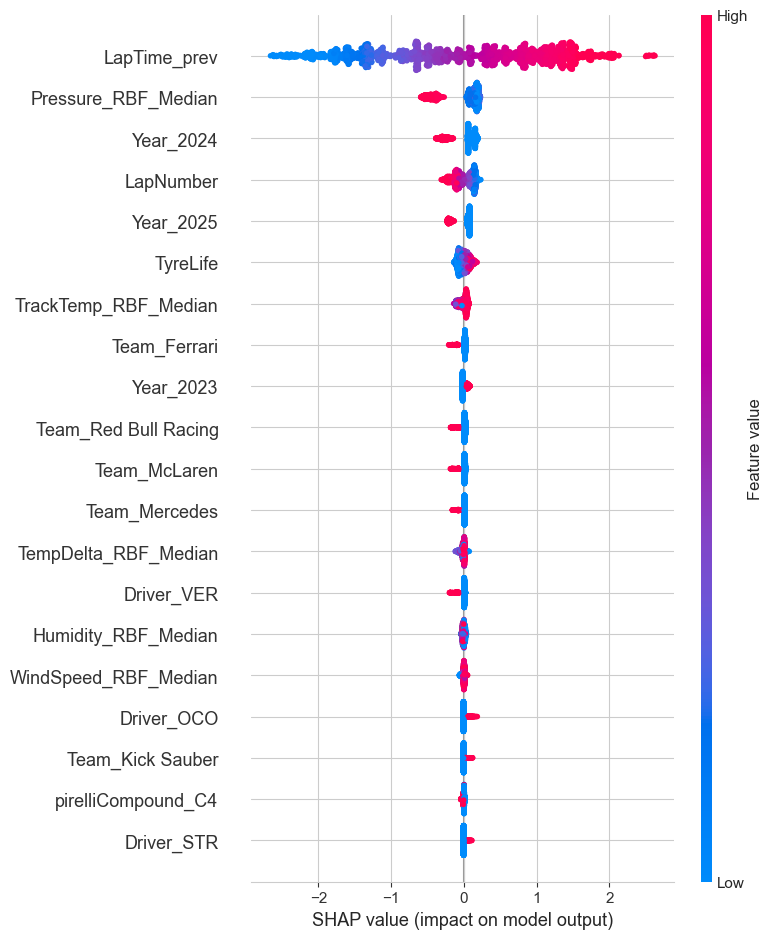

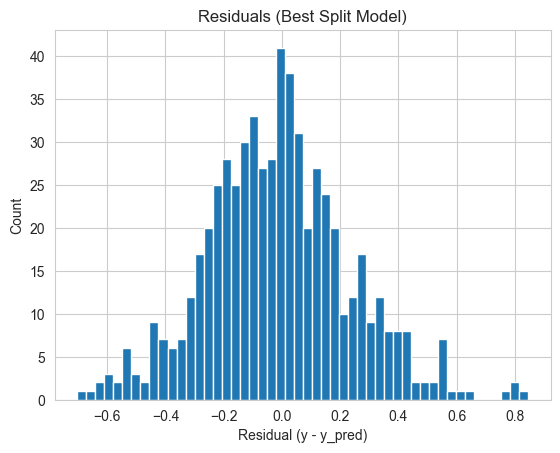

In [31]:
print("\nMelhor modelo do XGBoost treinado durante os splits:")
print("Seed:", best_seed)
print("R2:", best_r2)
print("RMSE:", best_rmse)
print("MAE:", best_mae)

importance = best_model.get_score(importance_type="gain")


if len(importance) > 0 and next(iter(importance.keys())).startswith("f"):
    colnames = list(best_X_tr.columns)
    importance_named = {colnames[int(k[1:])]: v for k, v in importance.items()}
else:
    importance_named = importance

importance_df = (
    pd.DataFrame.from_dict(importance_named, orient="index", columns=["gain"])
      .sort_values("gain", ascending=False)
)

display(importance_df.head(10))
shap.initjs()


explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(best_X_tr)

shap.summary_plot(shap_values, best_X_tr)


residuals_best = best_y_te.values - best_preds

plt.figure()
plt.hist(residuals_best, bins=50)
plt.title("Residuals (Best Split Model)")
plt.xlabel("Residual (y - y_pred)")
plt.ylabel("Count")
plt.savefig("residuals_best_model.png", bbox_inches="tight", dpi=300)
plt.show()

## 21. Visualização Definitiva: Comparação de Intervalos de Confiança (95%)

Tabelas numéricas são precisas, mas a visualização gráfica é essencial para a interpretação intuitiva da significância estatística.

Nesta etapa, geramos um gráfico de barras comparativo com **Barras de Erro (*Error Bars*)**, onde:
* **A Altura da Barra:** Representa a **Média** de desempenho nos 5 splits de validação.
* **A Linha Preta (Bigode):** Representa o **Intervalo de Confiança de 95%** (do limite inferior ao superior).

### Como ler este gráfico para a Monografia:
1.  **Teste de Sobreposição (*Overlap Test*):** Olhe para as linhas de erro pretas.
    * Se a linha do Baseline **cruzar** a linha do XGBoost (ou seja, se elas ocuparem a mesma faixa vertical em algum ponto), confirmamos visualmente o **Empate Técnico Estatístico**.
    * Se houver um vão claro entre elas, confirmamos a superioridade de um modelo.
2.  **Consistência:** Barras de erro curtas indicam um modelo estável (que performa igual independente do sorteio dos dados). Barras longas indicam instabilidade.
3.  **Magnitude do Ganho:** Mesmo havendo sobreposição, se a barra do XGBoost for consistentemente menor (no RMSE/MAE) ou maior (no R²), isso ilustra o ganho marginal de precisão obtido pela não-linearidade.

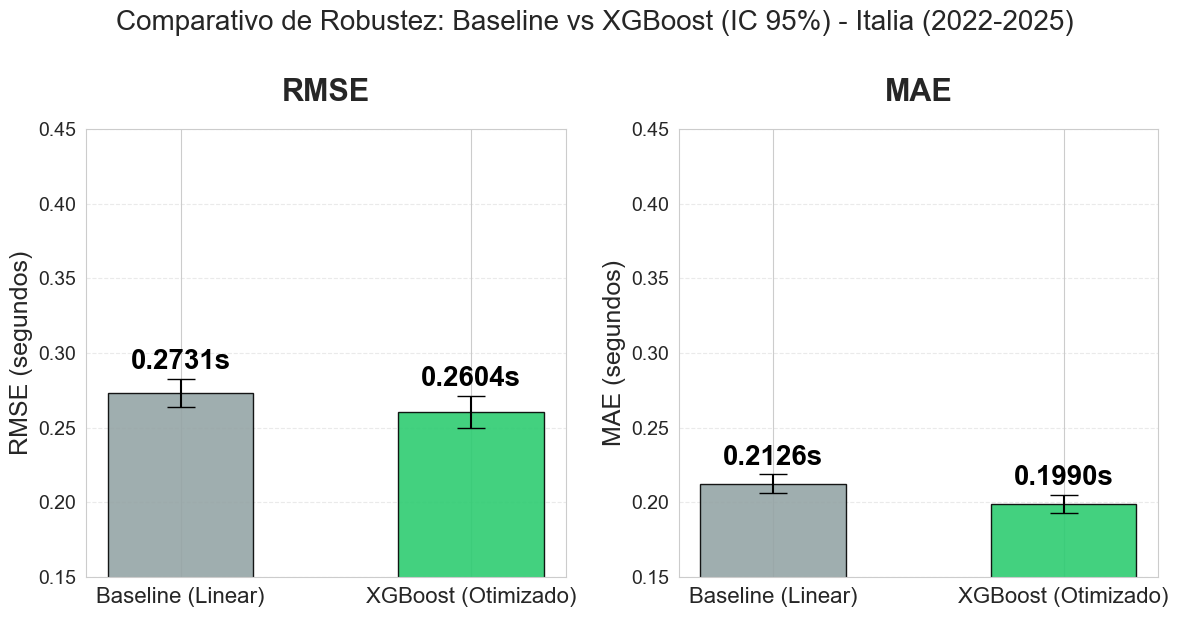

In [32]:
rmse_data = {
    'Baseline (Linear)': [mean_rmse_lr, lower_rmse_lr, upper_rmse_lr],
    'XGBoost (Otimizado)': [rmse_m_xgb, rmse_l_xgb, rmse_u_xgb]
}

mae_data = {
    'Baseline (Linear)': [mean_mae_lr, lower_mae_lr, upper_mae_lr],
    'XGBoost (Otimizado)': [mae_m_xgb, mae_l_xgb, mae_u_xgb]
}

def plot_confidence_intervals(data, metric_name, ax, higher_is_better=False):
    models = list(data.keys())
    means = [data[m][0] for m in models]

    yerr = np.array([
        [data[m][0] - data[m][1], data[m][2] - data[m][0]] for m in models
    ]).T

    colors = ['#95a5a6', '#2ecc71']

    bars = ax.bar(models, means, yerr=yerr, capsize=10,
                  color=colors, alpha=0.9, width=0.5, edgecolor='black', linewidth=1)

    for i, bar in enumerate(bars):
        height = bar.get_height()
        upper_limit = data[models[i]][2]

        label_pos = upper_limit + (upper_limit * 0.01)

        label_text = f'{height:.4f}s'

        ax.text(bar.get_x() + bar.get_width()/2., label_pos,
                label_text, ha='center', va='bottom', fontsize=20, fontweight='bold', color='black')

    ax.set_title(f'{metric_name}', fontsize=22, pad=20, fontweight='bold')
    ax.set_ylabel(f'{metric_name} (segundos)', fontsize=18)

    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.4)

    min_val = min(data[m][1] for m in models)
    max_val = max(data[m][2] for m in models)

    margin = (max_val - min_val) * 1.5

    ax.set_ylim(0.15, 0.45)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_confidence_intervals(rmse_data, 'RMSE', axes[0], higher_is_better=False)
plot_confidence_intervals(mae_data, 'MAE', axes[1], higher_is_better=False)

plt.suptitle('Comparativo de Robustez: Baseline vs XGBoost (IC 95%) - Italia (2022-2025)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
def preprocess_like_training(df_raw, cat_cols, num_cols, train_columns):
    Xp = df_raw.copy()

    cat_cols_use = [c for c in cat_cols if c in Xp.columns]
    num_cols_use = [c for c in num_cols if c in Xp.columns]

    Xp[cat_cols_use] = Xp[cat_cols_use].fillna("Missing")

    Xp = pd.get_dummies(Xp, columns=cat_cols_use, drop_first=True)

    Xp[num_cols_use] = Xp[num_cols_use].apply(lambda s: s.fillna(s.median()), axis=0)

    Xp = Xp.reindex(columns=train_columns, fill_value=0)

    return Xp


DRIVER_CODE = "VER"
YEAR_TARGET = 2025

RACE_COL = "Race"
RACE_NAME = 'Italian Grand Prix'

df_all_laps = laps_cleaned.copy()

mask = (df_all_laps["Year"] == YEAR_TARGET) & (df_all_laps["Driver"] == DRIVER_CODE)

if RACE_NAME is not None and RACE_COL in df_all_laps.columns:
    mask = mask & (df_all_laps[RACE_COL] == RACE_NAME)

df_driver = df_all_laps.loc[mask].copy()

df_driver = df_driver.sort_values("LapNumber")

print("Voltas encontradas:", df_driver.shape[0])
display(df_driver[["Year","Driver","LapNumber",'pirelliCompound','TyreLife']])

Voltas encontradas: 47


,Year,Driver,LapNumber,pirelliCompound,TyreLife
117,2025,VER,4.0,C4,4.0
155,2025,VER,5.0,C4,5.0
212,2025,VER,6.0,C4,6.0
270,2025,VER,7.0,C4,7.0
327,2025,VER,8.0,C4,8.0
382,2025,VER,9.0,C4,9.0
435,2025,VER,10.0,C4,10.0
485,2025,VER,11.0,C4,11.0
539,2025,VER,12.0,C4,12.0
593,2025,VER,13.0,C4,13.0


In [34]:
X_driver_raw = X_raw.loc[df_driver.index].copy()

X_driver_proc = preprocess_like_training(
    df_raw=X_driver_raw,
    cat_cols=cat_cols,
    num_cols=num_cols_base,
    train_columns=X.columns
)

d_driver = xgb.DMatrix(X_driver_proc, feature_names=list(X.columns))
driver_preds = best_model.predict(d_driver)

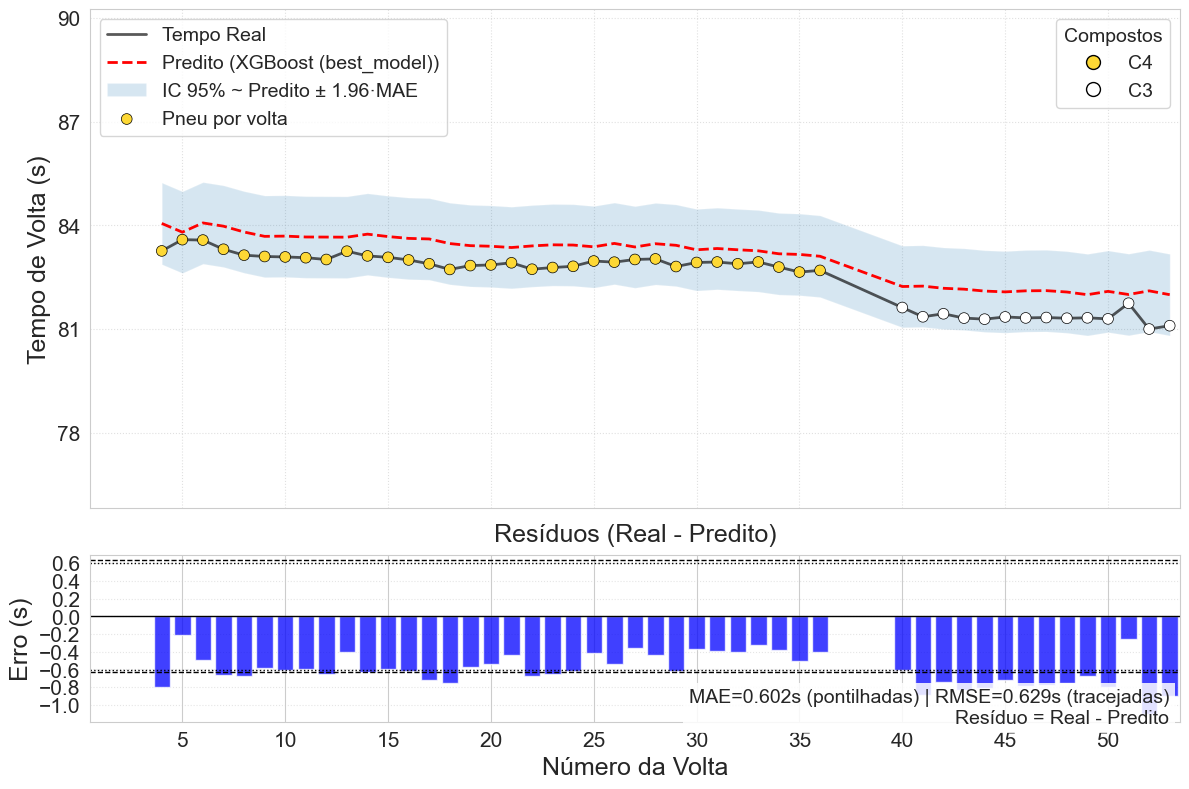

In [35]:
def plot_driver_timeseries_with_ci_combined_mae(
    df_laps, y_true, y_pred,
    tyre_col="pirelliCompound",
    model_label="XGBoost (best_model)",
    title_prefix="DRIVER - RACE 2025",
    y_offset_min=0.5,
    compounds=("C3", "C2", "C1"),
    x_tick_step=5,
    y1_tick_step=3,
    y2_tick_step=0.2,
    ci_level=0.95,
    ci_method="mae",
    ci_alpha=0.18
):
    df_plot = df_laps.copy().sort_values("LapNumber").copy()
    df_plot["Real"] = np.array(y_true)
    df_plot["Predito"] = np.array(y_pred)
    df_plot["Residuo"] = df_plot["Real"] - df_plot["Predito"]

    mae = np.mean(np.abs(df_plot["Residuo"]))
    rmse = np.sqrt(np.mean(df_plot["Residuo"] ** 2))

    if tyre_col in df_plot.columns:
        df_plot["Tyre_norm"] = df_plot[tyre_col].astype(str).str.upper().str.strip()
    else:
        df_plot["Tyre_norm"] = "UNK"

    ramp_colors = ["#e53935", "#fdd835", "#ffffff"]
    compounds = tuple([str(c).upper().strip() for c in compounds])
    if len(compounds) != 3:
        raise ValueError("O argumento 'compounds' deve ter exatamente 3 valores.")

    tyre_colors = {compounds[i]: ramp_colors[i] for i in range(3)}
    point_colors = df_plot["Tyre_norm"].map(tyre_colors).fillna("#9e9e9e")

    max_lap = float(df_plot["LapNumber"].max())
    xlim = (0.5, max_lap + 0.5)

    z_map = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_map.get(ci_level, 1.96)

    if ci_method == "rmse":
        sigma = rmse
        ci_label = f"IC {int(ci_level*100)}% ~ Predito ± {z:.2f}·RMSE"
    elif ci_method == "mae":
        sigma = mae
        ci_label = f"IC {int(ci_level*100)}% ~ Predito ± {z:.2f}·MAE"
    elif ci_method == "std":
        sigma = np.std(df_plot["Residuo"], ddof=1)
        ci_label = f"IC {int(ci_level*100)}% ~ Predito ± {z:.2f}·STD"
    else:
        raise ValueError("ci_method deve ser 'rmse', 'mae' ou 'std'.")

    ci_low = df_plot["Predito"] - z * sigma
    ci_high = df_plot["Predito"] + z * sigma

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    sns.lineplot(
        data=df_plot, x="LapNumber", y="Real", ax=ax1,
        label="Tempo Real", color="black", alpha=0.65, linewidth=2, errorbar=None
    )
    sns.lineplot(
        data=df_plot, x="LapNumber", y="Predito", ax=ax1,
        label=f"Predito ({model_label})", color="red", linestyle="--", linewidth=2, errorbar=None
    )

    ax1.fill_between(
        df_plot["LapNumber"].values,
        ci_low.values,
        ci_high.values,
        alpha=ci_alpha,
        label=ci_label
    )

    ax1.scatter(
        df_plot["LapNumber"], df_plot["Real"],
        c=point_colors, s=60, edgecolors="black", linewidths=0.5, zorder=5,
        label="Pneu por volta"
    )


    ax1.set_ylabel("Tempo de Volta (s)", fontsize=18)
    ax1.tick_params(axis='both', which='major', labelsize=15)
    ax1.grid(True, linestyle=":", alpha=0.6)

    y_min = min(df_plot["Real"].min(), df_plot["Predito"].min(), ci_low.min()) - 5
    y_max = max(df_plot["Real"].max(), df_plot["Predito"].max(), ci_high.max()) + 5
    ax1.set_ylim(y_min, y_max)

    tyres_present = set(df_plot["Tyre_norm"].unique())
    ordered_tyres = [t for t in compounds if t in tyres_present]
    extras = sorted([t for t in tyres_present if t not in compounds])
    ordered_tyres += extras

    compound_handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=10,
               markerfacecolor=tyre_colors.get(t, "#9e9e9e"),
               markeredgecolor="black", label=t)
        for t in ordered_tyres
    ]

    leg_main = ax1.legend(loc="upper left", fontsize=14)
    leg_comp = ax1.legend(handles=compound_handles, title="Compostos", loc="upper right", frameon=True, fontsize=14, title_fontsize=14)
    ax1.add_artist(leg_main)

    ax1.set_xlim(*xlim)
    ax1.xaxis.set_major_locator(MultipleLocator(x_tick_step))
    ax1.yaxis.set_major_locator(MultipleLocator(y1_tick_step))

    colors = np.where(df_plot["Residuo"] >= 0, "red", "blue")
    ax2.bar(df_plot["LapNumber"], df_plot["Residuo"], color=colors, alpha=0.75)
    ax2.axhline(0, color="black", linewidth=1)

    ax2.axhline(+mae, color="black", linestyle=":", linewidth=1)
    ax2.axhline(-mae, color="black", linestyle=":", linewidth=1)
    ax2.axhline(+rmse, color="black", linestyle="--", linewidth=1)
    ax2.axhline(-rmse, color="black", linestyle="--", linewidth=1)

    ax2.text(
        0.99, 0.2,
        f"MAE={mae:.3f}s (pontilhadas) | RMSE={rmse:.3f}s (tracejadas)\nResíduo = Real - Predito",
        transform=ax2.transAxes,
        fontsize=14,
        ha="right",
        va="top",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax2.set_title("Resíduos (Real - Predito)", fontsize=18, pad=10)
    ax2.set_ylabel("Erro (s)", fontsize=18)
    ax2.set_xlabel("Número da Volta", fontsize=18)
    ax2.tick_params(axis='both', which='major', labelsize=15)

    ax2.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax2.set_xlim(*xlim)
    ax2.xaxis.set_major_locator(MultipleLocator(x_tick_step))
    ax2.yaxis.set_major_locator(MultipleLocator(y2_tick_step))

    fig.tight_layout()
    plt.show()

    return df_plot

df_driver_plot = plot_driver_timeseries_with_ci_combined_mae(
    df_laps=df_driver,
    y_true=df_driver[target_col].values,
    y_pred=driver_preds,
    title_prefix=f"{DRIVER_CODE} - {RACE_NAME} 2025",
    compounds=("C5", "C4", "C3"),
    y_offset_min=0.5,
    ci_level=0.95,
    ci_method="mae"
)

In [36]:
years = sorted(X_raw['Year'].unique())  # [2022, 2023, 2024, 2025]
loyo_results = {"year_holdout": [], "rmse": [], "mae": [], "r2": []}

for holdout_year in years:
    X_train_loyo = X_proc[X_raw['Year'] != holdout_year]
    X_test_loyo = X_proc[X_raw['Year'] == holdout_year]
    y_train_loyo = y_raw[X_raw['Year'] != holdout_year]
    y_test_loyo = y_raw[X_raw['Year'] == holdout_year]
    
    # Treinar com best_params do Optuna
    dtr = xgb.DMatrix(X_train_loyo, label=y_train_loyo)
    dte = xgb.DMatrix(X_test_loyo, label=y_test_loyo)
    
    bst = xgb.train(
        params=optuna_params_train,
        dtrain=dtr,
        num_boost_round=5000,
        evals=[(dte, "validation")],
        early_stopping_rounds=100,
        verbose_eval=False
    )
    preds = bst.predict(dte)
    
    loyo_results["year_holdout"].append(holdout_year)
    loyo_results["rmse"].append(np.sqrt(mean_squared_error(y_test_loyo, preds)))
    loyo_results["mae"].append(mean_absolute_error(y_test_loyo, preds))
    loyo_results["r2"].append(r2_score(y_test_loyo, preds))

print("\n--- Resultados LOYO por Ano ---")
for i in range(len(years)):
    print(f"Ano Holdout: {loyo_results['year_holdout'][i]} | RMSE: {loyo_results['rmse'][i]:.4f} | MAE: {loyo_results['mae'][i]:.4f} | R2: {loyo_results['r2'][i]:.4f}")
    


--- Resultados LOYO por Ano ---
Ano Holdout: 2022 | RMSE: 0.8228 | MAE: 0.7293 | R2: 0.3162
Ano Holdout: 2023 | RMSE: 0.8706 | MAE: 0.8192 | R2: -0.7178
Ano Holdout: 2024 | RMSE: 0.7174 | MAE: 0.6125 | R2: 0.6003
Ano Holdout: 2025 | RMSE: 1.1395 | MAE: 1.0808 | R2: -0.4013


In [ ]:
LAP_COL = "LapNumber"
WINDOW_RATIO = 0.15
TRAIN_RATIO = 0.80
TEST_RATIO = 0.20
SLIDE_STEP = 1

if LAP_COL not in X_raw.columns:
    raise ValueError(f"Coluna '{LAP_COL}' nao encontrada em X_raw.")

lap_min = int(X_raw[LAP_COL].min())
lap_max = int(X_raw[LAP_COL].max())
total_laps = lap_max - lap_min + 1

window_laps = max(2, int(np.round(total_laps * WINDOW_RATIO)))
train_size = max(1, int(np.floor(window_laps * TRAIN_RATIO)))
test_size = max(1, window_laps - train_size)

# Garante que treino + teste fechem exatamente a janela de 30%.
if train_size + test_size > window_laps:
    test_size = window_laps - train_size
if test_size < 1:
    test_size = 1
    train_size = window_laps - 1

print(f"Range de voltas disponivel: {lap_min}..{lap_max}")
print(f"Total de voltas: {total_laps}")
print(
    f"Janela universal = {WINDOW_RATIO:.0%} da corrida => {window_laps} voltas | "
    f"train_size = {train_size} ({TRAIN_RATIO:.0%}) | test_size = {test_size} ({TEST_RATIO:.0%})"
)

wf_results = {
    "fold": [],
    "window_range": [],
    "train_range": [],
    "test_range": [],
    "n_train": [],
    "n_test": [],
    "best_iter": [],
    "rmse": [],
    "mae": [],
    "r2": []
}

fold = 1
window_start = lap_min
window_last_start = lap_max - window_laps + 1

# A janela desliza de 1 em 1 volta.
while window_start <= window_last_start:
    window_end = window_start + window_laps - 1
    train_start = window_start
    train_end = train_start + train_size - 1
    test_start = train_end + 1
    test_end = window_end

    mask_train = (X_raw[LAP_COL] >= train_start) & (X_raw[LAP_COL] <= train_end)
    mask_test = (X_raw[LAP_COL] >= test_start) & (X_raw[LAP_COL] <= test_end)

    X_train_wf = X_proc.loc[mask_train]
    y_train_wf = y_raw.loc[mask_train]
    X_test_wf = X_proc.loc[mask_test]
    y_test_wf = y_raw.loc[mask_test]

    if len(X_train_wf) > 0 and len(X_test_wf) > 0:
        dtr = xgb.DMatrix(X_train_wf, label=y_train_wf)
        dte = xgb.DMatrix(X_test_wf, label=y_test_wf)

        num_boost_round = int(best_n) if "best_n" in globals() and best_n else 500

        bst = xgb.train(
            params=optuna_params_train,
            dtrain=dtr,
            num_boost_round=num_boost_round,
            verbose_eval=False
        )

        preds = bst.predict(dte)

        rmse_val = np.sqrt(mean_squared_error(y_test_wf, preds))
        mae_val = mean_absolute_error(y_test_wf, preds)
        r2_val = r2_score(y_test_wf, preds)

        wf_results["fold"].append(fold)
        wf_results["window_range"].append(f"{window_start}-{window_end}")
        wf_results["train_range"].append(f"{train_start}-{train_end}")
        wf_results["test_range"].append(f"{test_start}-{test_end}")
        wf_results["n_train"].append(len(X_train_wf))
        wf_results["n_test"].append(len(X_test_wf))
        wf_results["best_iter"].append(int(num_boost_round))
        wf_results["rmse"].append(float(rmse_val))
        wf_results["mae"].append(float(mae_val))
        wf_results["r2"].append(float(r2_val))

        print(
            f"Fold {fold:02d} | Janela {window_start}-{window_end} | "
            f"Train {train_start}-{train_end} | Test {test_start}-{test_end} | "
            f"n_train={len(X_train_wf)} n_test={len(X_test_wf)} | "
            f"RMSE={rmse_val:.4f} MAE={mae_val:.4f} R2={r2_val:.4f}"
        )
        fold += 1

    window_start += SLIDE_STEP


df_wf = pd.DataFrame(wf_results)

print("\n--- Resumo Walk-Forward Universal ---")
display(df_wf)

if len(df_wf) > 1:
    print("Medias globais:")
    print(f"RMSE medio: {df_wf['rmse'].mean():.4f}")
    print(f"MAE  medio: {df_wf['mae'].mean():.4f}")
    print(f"R2   medio: {df_wf['r2'].mean():.4f}")
else:
    print("Poucos folds para media robusta.")

# Comparar o modelo original em cenários de série temporal pela janela, pra ser uma comparação justo

Range de voltas disponivel: 3..53
Total de voltas: 51
Janela universal = 15% da corrida => 8 voltas | train_size = 6 (80%) | test_size = 2 (20%)
Fold 01 | Janela 3-10 | Train 3-8 | Test 9-10 | n_train=403 n_test=142 | RMSE=0.3188 MAE=0.2537 R2=0.9499
Fold 02 | Janela 4-11 | Train 4-9 | Test 10-11 | n_train=420 n_test=135 | RMSE=0.2713 MAE=0.2155 R2=0.9659
Fold 03 | Janela 5-12 | Train 5-10 | Test 11-12 | n_train=422 n_test=112 | RMSE=0.2609 MAE=0.2018 R2=0.9684
Fold 04 | Janela 6-13 | Train 6-11 | Test 12-13 | n_train=420 n_test=106 | RMSE=0.2617 MAE=0.2041 R2=0.9674
Fold 05 | Janela 7-14 | Train 7-12 | Test 13-14 | n_train=400 n_test=123 | RMSE=0.3026 MAE=0.2428 R2=0.9612
Fold 06 | Janela 8-15 | Train 8-13 | Test 14-15 | n_train=387 n_test=126 | RMSE=0.3013 MAE=0.2500 R2=0.9637
Fold 07 | Janela 9-16 | Train 9-14 | Test 15-16 | n_train=377 n_test=122 | RMSE=0.2808 MAE=0.2234 R2=0.9689
Fold 08 | Janela 10-17 | Train 10-15 | Test 16-17 | n_train=367 n_test=122 | RMSE=0.2739 MAE=0.2101 R2

,fold,window_range,train_range,test_range,n_train,n_test,best_iter,rmse,mae,r2
0,1,3-10,3-8,9-10,403,142,910,0.318849,0.253680,0.949940
1,2,4-11,4-9,10-11,420,135,910,0.271257,0.215476,0.965907
2,3,5-12,5-10,11-12,422,112,910,0.260890,0.201800,0.968401
3,4,6-13,6-11,12-13,420,106,910,0.261709,0.204077,0.967365
4,5,7-14,7-12,13-14,400,123,910,0.302636,0.242841,0.961156
5,6,8-15,8-13,14-15,387,126,910,0.301257,0.249984,0.963733
6,7,9-16,9-14,15-16,377,122,910,0.280762,0.223360,0.968932
7,8,10-17,10-15,16-17,367,122,910,0.273862,0.210143,0.969547
8,9,11-18,11-16,17-18,357,124,910,0.271964,0.212324,0.970310
9,10,12-19,12-17,18-19,354,120,910,0.286804,0.216877,0.966184


Medias globais:
RMSE medio: 0.3135
MAE  medio: 0.2462
R2   medio: 0.9626
